<a href="https://colab.research.google.com/github/brijeshksingh/AIML_Colab_repo/blob/main/House_price_pred_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
!pip install catboost
!pip install xgboost

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


In [75]:
df = pd.read_csv('/content/Week 11_Graded Mini Project_Dataset_houseprice.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [76]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [77]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [78]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### 1.1	Handling Missing Values: Identify and handle missing values appropriately.

<Axes: >

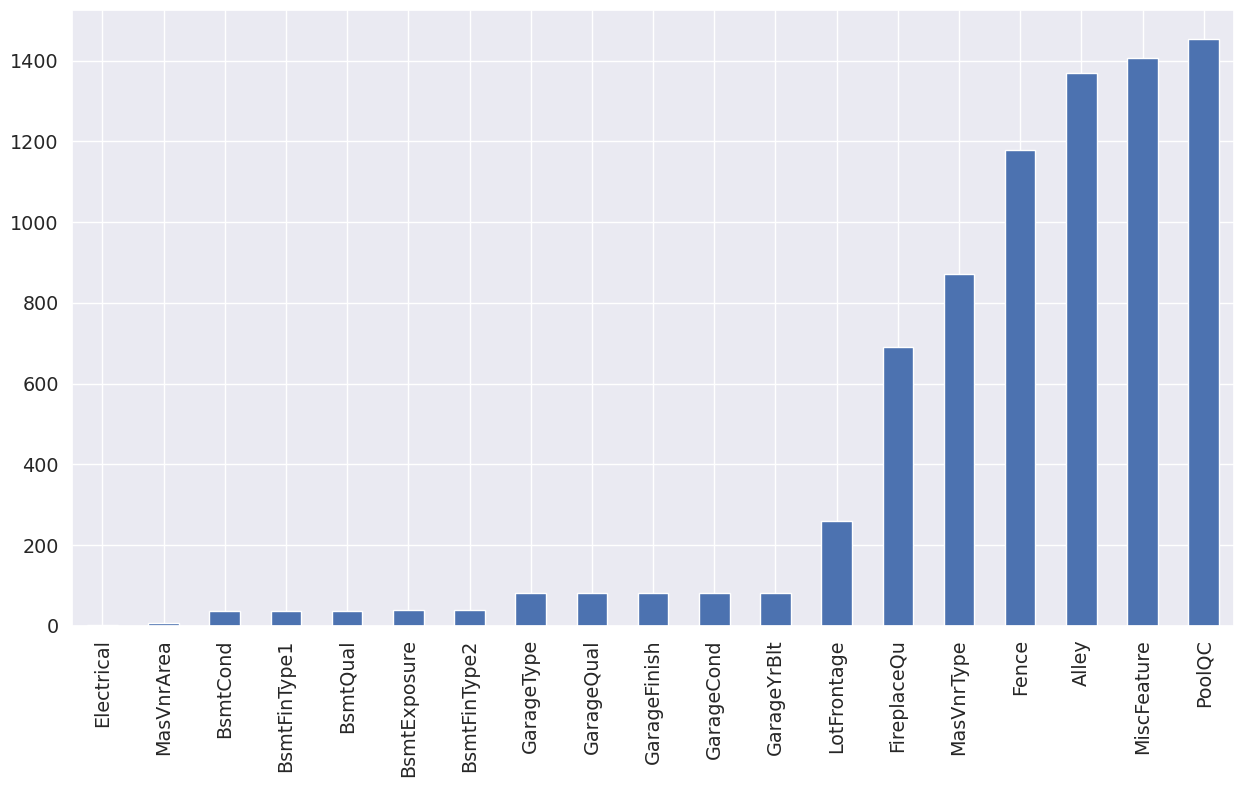

In [79]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
plt.figure(figsize=(15, 8))
missing.plot.bar()

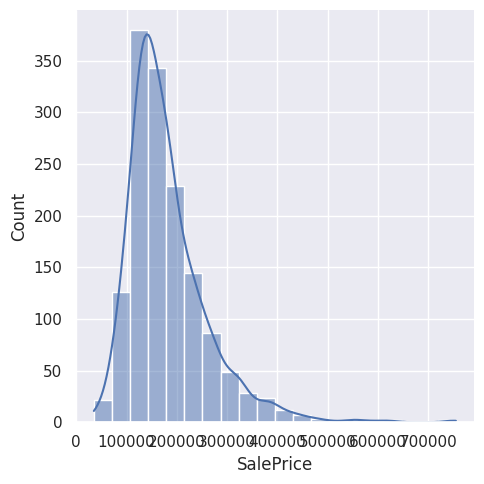

In [80]:
sns.set(rc={'figure.figsize':(15,8)})
sns.displot(df['SalePrice'],kde=True,  bins=20);

In [81]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
Alley,1369
LotShape,0
LandContour,0
Utilities,0


<Axes: >

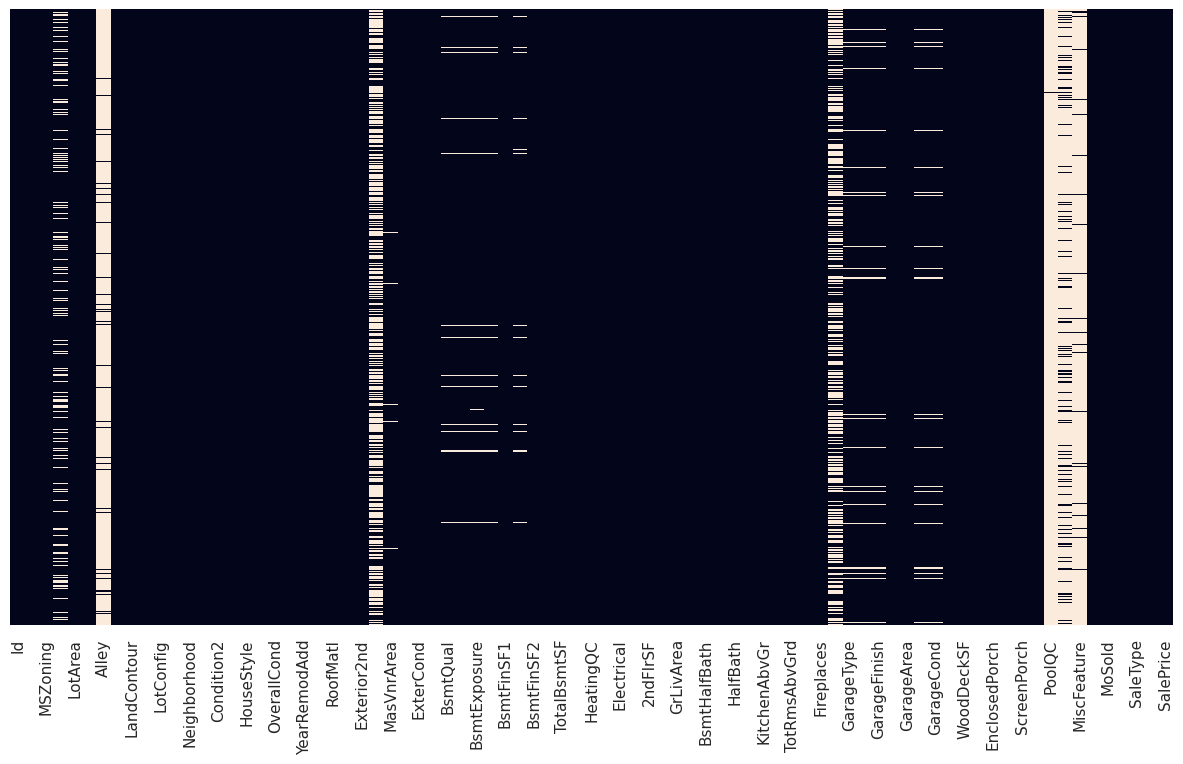

In [82]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [83]:
df.shape

(1460, 81)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [85]:
df.LotFrontage  = df.LotFrontage.fillna(df.LotFrontage.mean())

In [86]:
df.Alley.isnull().sum()

np.int64(1369)

In [87]:
df.Alley = df.drop(columns=['Alley'], inplace=True)

In [88]:
df.MSZoning = df.MSZoning.fillna(df.MSZoning.mode()[0])
df.BsmtCond = df.BsmtCond.fillna(df.BsmtCond.mode()[0])
df.BsmtQual = df.BsmtQual.fillna(df.BsmtQual.mode()[0])
df.FireplaceQu = df.FireplaceQu.fillna(df.FireplaceQu.mode()[0])
df.GarageType = df.GarageType.fillna(df.GarageType.mode()[0])
df.GarageFinish = df.GarageFinish.fillna(df.GarageFinish.mode()[0])
df.GarageQual = df.GarageQual.fillna(df.GarageQual.mode()[0])
df.GarageCond = df.GarageCond.fillna(df.GarageCond.mode()[0])
df.drop(columns=['GarageYrBlt'], axis=1, inplace=True)
df.drop(columns=['PoolQC', 'Fence', 'MiscFeature'], axis=1, inplace=True)

In [89]:
df.shape

(1460, 76)

In [90]:
df.drop(columns=['Id'], axis=1, inplace=True)

In [91]:
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0
LandSlope,0


In [92]:
df.MasVnrArea = df.MasVnrArea.fillna(df.MasVnrArea.mode()[0])
df.MasVnrType = df.MasVnrType.fillna(df.MasVnrType.mode()[0])

<Axes: >

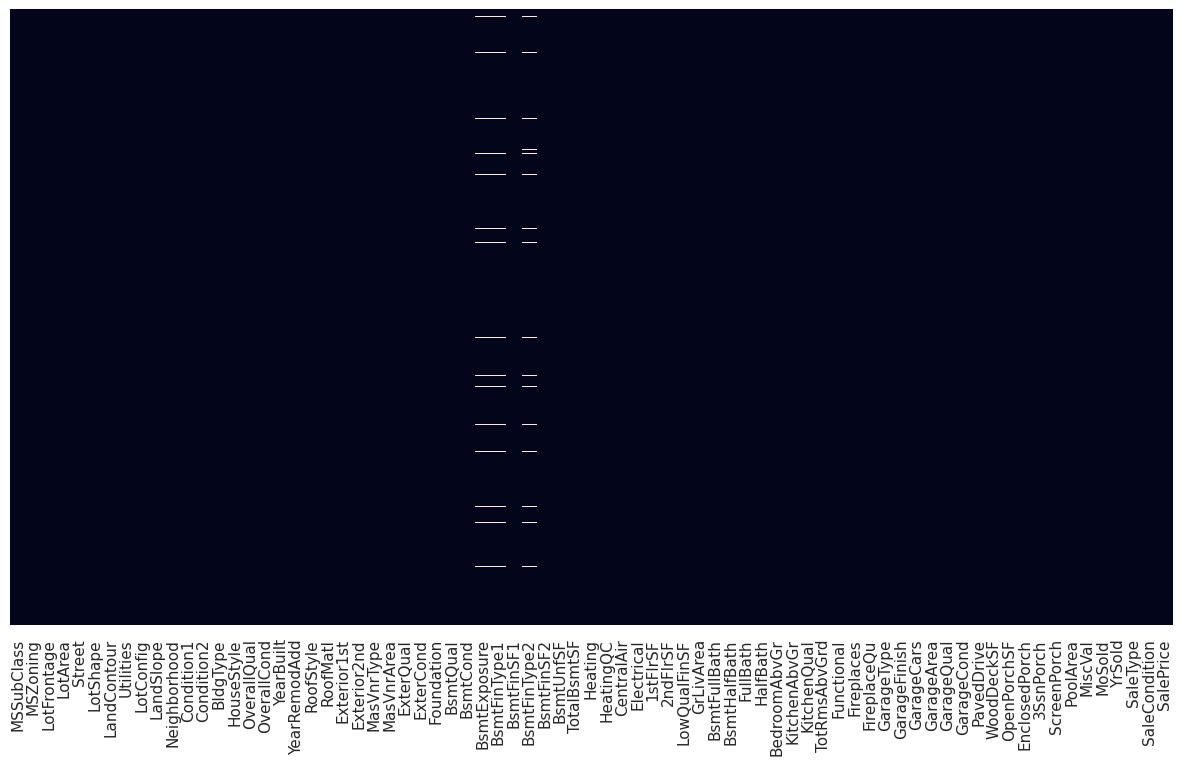

In [93]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [94]:
df.BsmtExposure = df.BsmtExposure.fillna(df.BsmtExposure.mode()[0])
df.BsmtFinType1 = df.BsmtFinType1.fillna(df.BsmtFinType1.mode()[0])
df.BsmtFinType2 = df.BsmtFinType2.fillna(df.BsmtFinType2.mode()[0])

<Axes: >

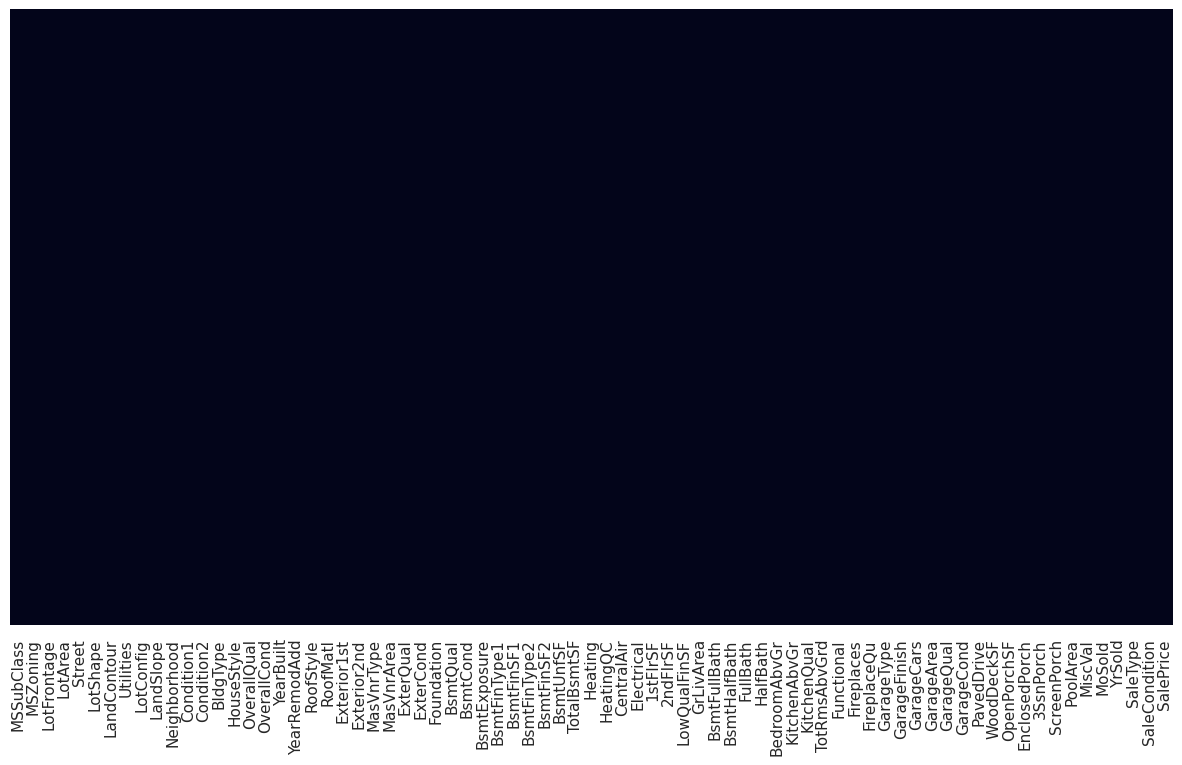

In [95]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [96]:
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0
LandSlope,0


In [97]:
df.dropna(inplace=True)

In [98]:
df.shape

(1459, 75)

In [99]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Gd,Attchd,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,BrkFace,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,BrkFace,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


### 1.2	Converting Categorical Variables: Encode categorical variables using suitable methods (e.g., one-hot encoding).

In [100]:
categorical_features = df.select_dtypes(include='object').columns
categorical_features

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [101]:
final_df = df.copy()
final_df.shape

(1459, 75)

In [102]:
def category_onehot_multcols(multcolumns):
    df_final=final_df
    i=0
    for fields in multcolumns:


        df1=pd.get_dummies(final_df[fields],drop_first=True)

        final_df.drop([fields],axis=1,inplace=True)
        if i==0:
            df_final=df1.copy()
        else:

            df_final=pd.concat([df_final,df1],axis=1)
        i=i+1


    df_final=pd.concat([final_df,df_final],axis=1)

    return df_final

In [103]:
final_df=category_onehot_multcols(categorical_features)

In [104]:
final_df = final_df.loc[:,~final_df.columns.duplicated()]
print(f"Shape after removing duplicates: {final_df.shape}")

Shape after removing duplicates: (1459, 175)


In [105]:
final_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,FV,RH,RL,RM,Pave,IR2,IR3,Reg,HLS,Low,Lvl,NoSeWa,CulDSac,FR2,FR3,Inside,Mod,Sev,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,MeadowV,Mitchel,NAmes,NPkVill,NWAmes,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker,Feedr,Norm,PosA,PosN,RRAe,RRAn,RRNe,RRNn,2fmCon,Duplex,Twnhs,TwnhsE,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl,Gable,Gambrel,Hip,Mansard,Shed,CompShg,Membran,Metal,Roll,Tar&Grv,WdShake,WdShngl,AsphShn,BrkComm,BrkFace,CBlock,CemntBd,HdBoard,ImStucc,MetalSd,Plywood,Stone,Stucco,VinylSd,Wd Sdng,WdShing,Brk Cmn,CmentBd,Other,Wd Shng,Fa,Gd,TA,Po,PConc,Slab,Wood,Mn,No,BLQ,GLQ,LwQ,Rec,Unf,GasA,GasW,Grav,OthW,Wall,Y,FuseF,FuseP,Mix,SBrkr,Maj2,Min1,Min2,Typ,Attchd,Basment,BuiltIn,CarPort,Detchd,RFn,P,CWD,Con,ConLD,ConLI,ConLw,New,Oth,WD,AdjLand,Alloca,Family,Normal,Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2,548,0,61,0,0,0,0,0,2,2008,208500,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,2,460,298,0,0,0,0,0,0,5,2007,181500,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2,608,0,42,0,0,0,0,0,9,2008,223500,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,T

### 1.3	Normalising Numerical Features: Normalise numerical features to ensure they are on a comparable scale

In [106]:
# Identify numerical columns
numerical_features = final_df.select_dtypes(include=np.number).columns.tolist()

# Exclude the target variable 'SalePrice' if it's in the numerical features
if 'SalePrice' in numerical_features:
    numerical_features.remove('SalePrice')

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical features of the final_df
final_df[numerical_features] = scaler.fit_transform(final_df[numerical_features])

final_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,FV,RH,RL,RM,Pave,IR2,IR3,Reg,HLS,Low,Lvl,NoSeWa,CulDSac,FR2,FR3,Inside,Mod,Sev,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,MeadowV,Mitchel,NAmes,NPkVill,NWAmes,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker,Feedr,Norm,PosA,PosN,RRAe,RRAn,RRNe,RRNn,2fmCon,Duplex,Twnhs,TwnhsE,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl,Gable,Gambrel,Hip,Mansard,Shed,CompShg,Membran,Metal,Roll,Tar&Grv,WdShake,WdShngl,AsphShn,BrkComm,BrkFace,CBlock,CemntBd,HdBoard,ImStucc,MetalSd,Plywood,Stone,Stucco,VinylSd,Wd Sdng,WdShing,Brk Cmn,CmentBd,Other,Wd Shng,Fa,Gd,TA,Po,PConc,Slab,Wood,Mn,No,BLQ,GLQ,LwQ,Rec,Unf,GasA,GasW,Grav,OthW,Wall,Y,FuseF,FuseP,Mix,SBrkr,Maj2,Min1,Min2,Typ,Attchd,Basment,BuiltIn,CarPort,Detchd,RFn,P,CWD,Con,ConLD,ConLI,ConLw,New,Oth,WD,AdjLand,Alloca,Family,Normal,Partial
0,0.073732,-0.229203,-0.207125,0.650852,-0.517424,1.051899,0.879449,0.513594,0.574748,-0.28876,-0.944607,-0.460570,-0.794191,1.162093,-0.120284,0.370055,1.107124,-0.241148,0.790180,1.228641,0.163837,-0.211529,0.912128,-0.951848,0.311842,0.350660,-0.751887,0.215983,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,-1.599030,0.138826,208500,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,-0.871979,0.451876,-0.091909,-0.072372,2.178727,0.157540,-0.428864,-0.571009,1.171304,-0.28876,-0.641330,0.465629,0.256426,-0.794554,-0.120284,-0.482514,-0.820434,3.947370,0.790180,-0.760912,0.163837,-0.211529,-0.318380,0.599824,0.311842,-0.060947,1.625670,-0.704845,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,-0.489318,-0.614137,181500,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,0.073732,-0.092987,0.073401,0.650852,-0.517424,0.985650,0.830993,0.325449,0.092239,-0.28876,-0.301842,-0.314568,-0.628576,1.189587,-0.120284,0.514687,1.107124,-0.241148,0.790180,1.228641,0.163837,-0.211529,-0.318380,0.599824,0.311842,0.631301,-0.751887,-0.070832,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,0.990298,0.138826,223500,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,F

### 1.4	Outlier Detection: Identify and handle outliers in the dataset.

<Axes: xlabel='SalePrice'>

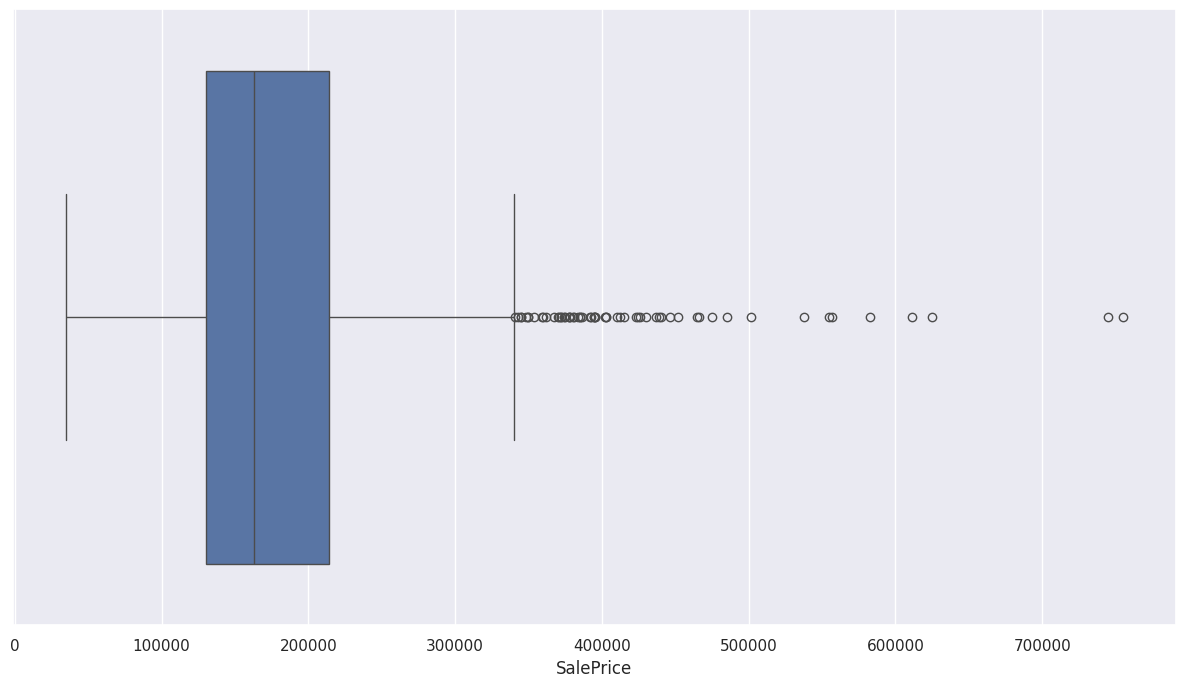

In [107]:
sns.boxplot(x=final_df['SalePrice'])

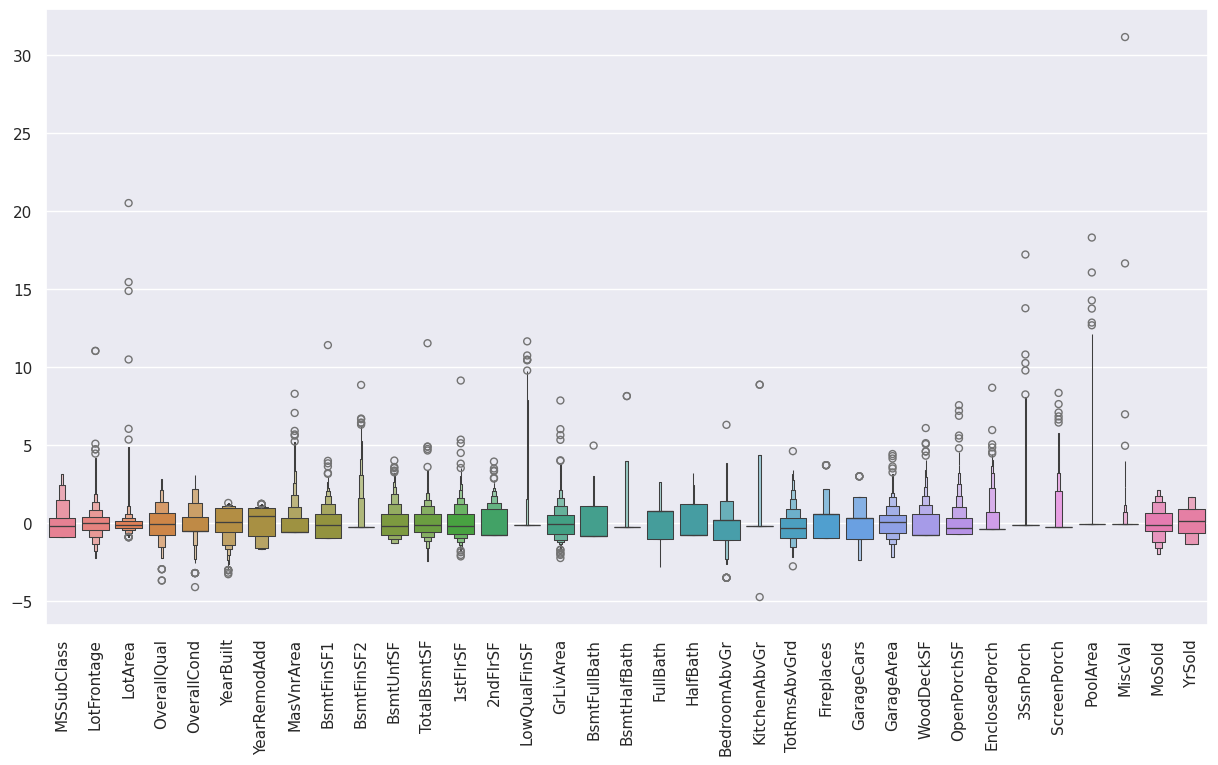

In [108]:
sns.boxenplot(data=final_df[numerical_features])
plt.xticks(rotation=90)
plt.show()

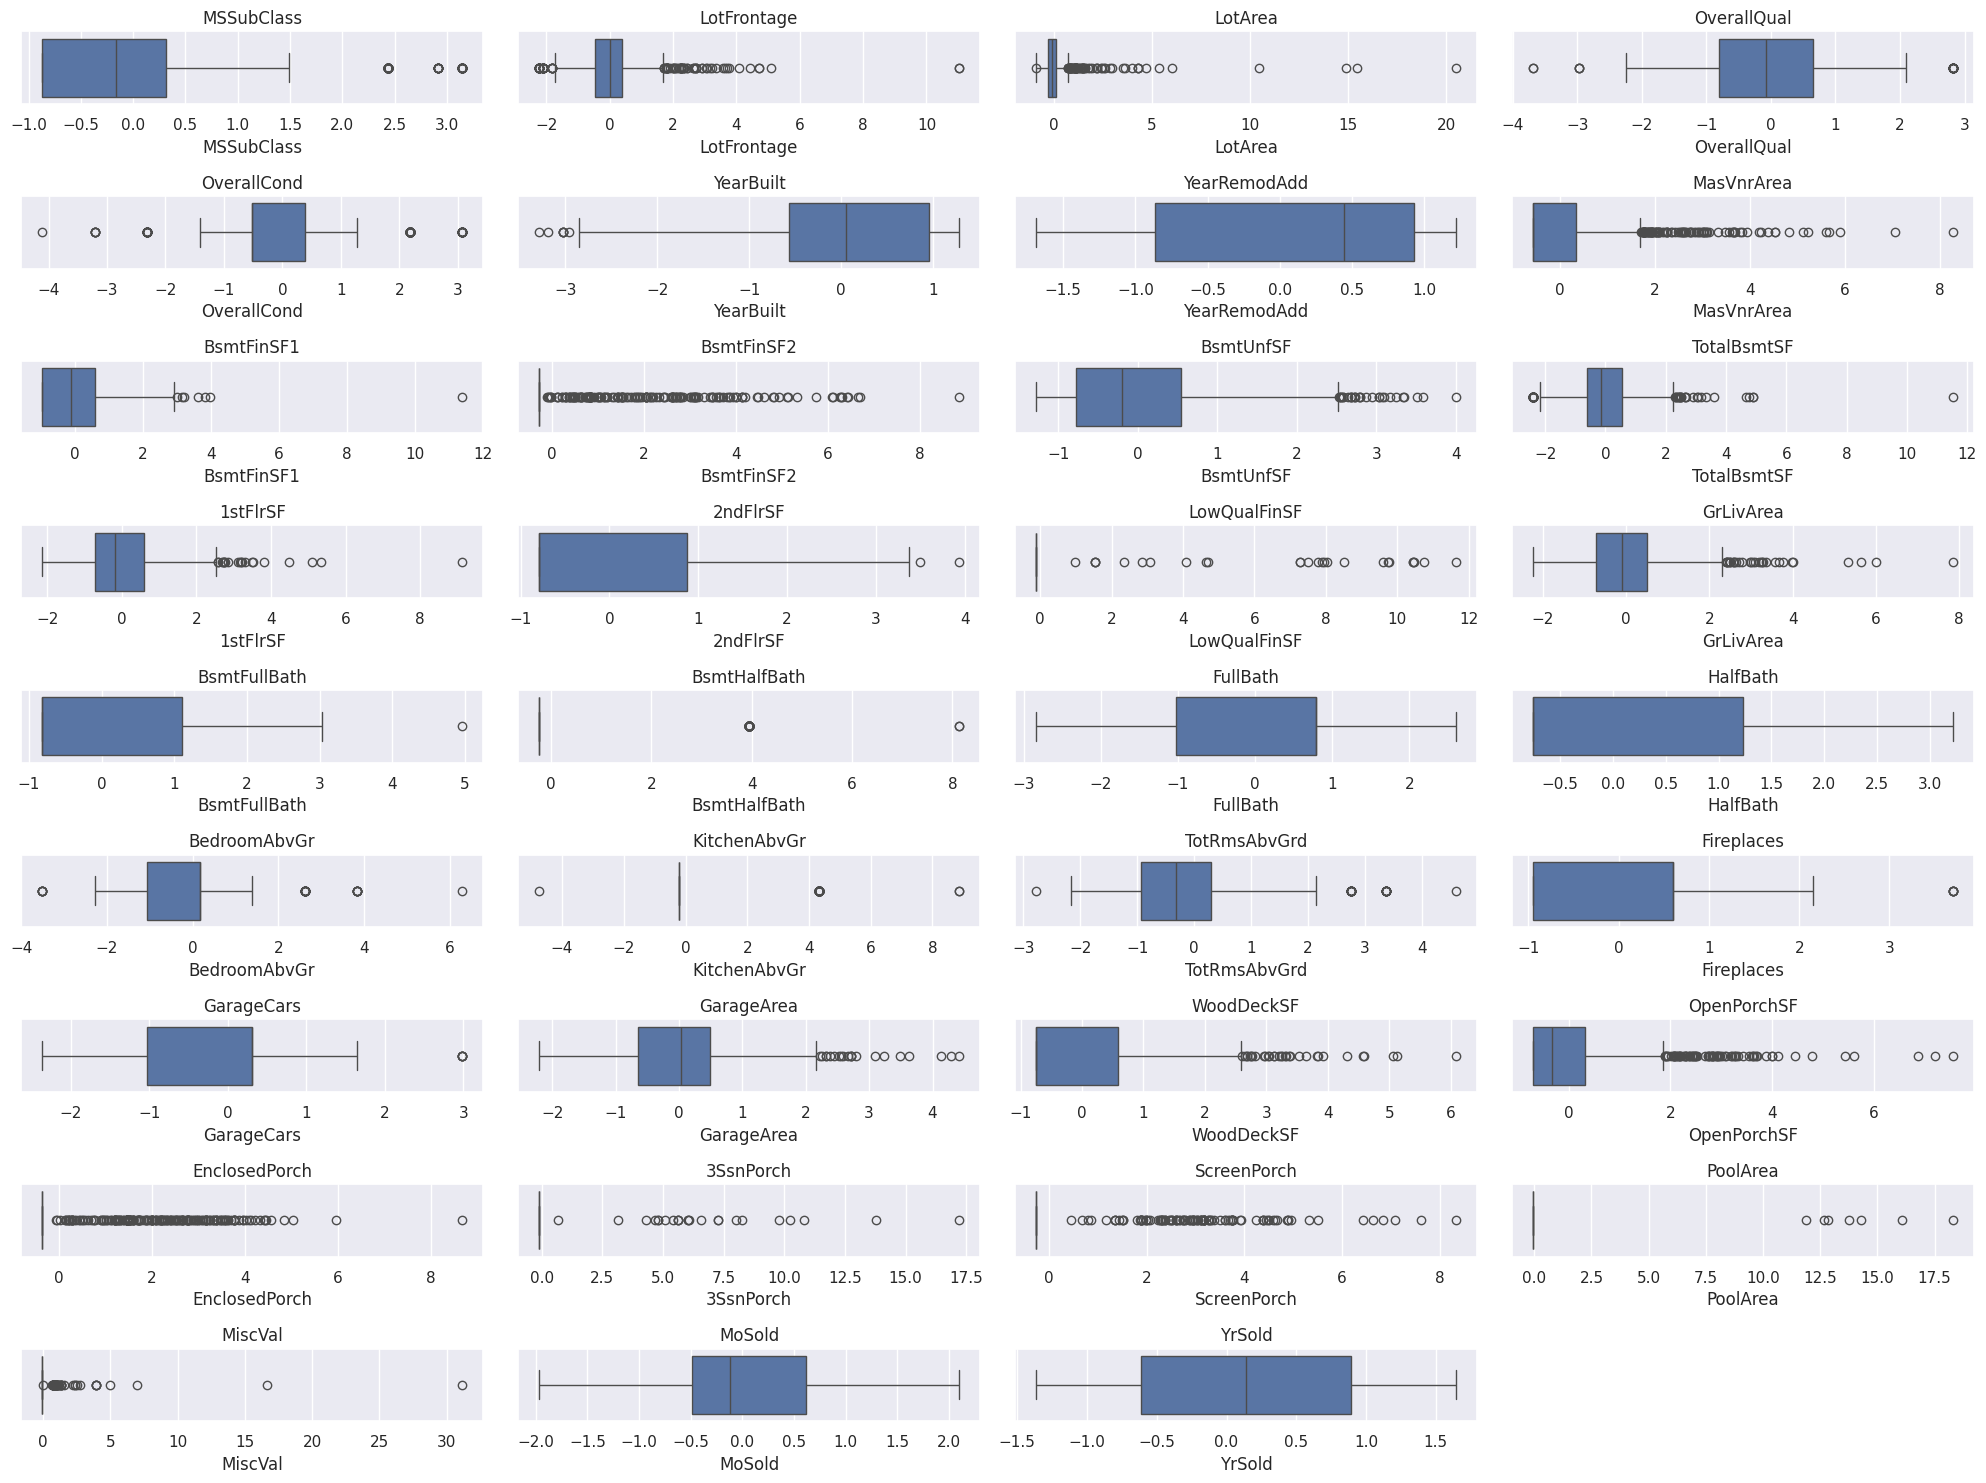

In [109]:
import math

# Identify numerical columns again, as they might have been normalized
numerical_features_for_plot = final_df.select_dtypes(include=np.number).columns.tolist()

# Exclude the target variable 'SalePrice' if it's in the numerical features
if 'SalePrice' in numerical_features_for_plot:
    numerical_features_for_plot.remove('SalePrice')

# Plot boxplots for each numerical feature to visualize outliers
plt.figure(figsize=(20, 15)) # Adjust figure size as needed

for i, col in enumerate(numerical_features_for_plot):
    plt.subplot(math.ceil(len(numerical_features_for_plot)/4), 4, i + 1) # Create subplots
    sns.boxplot(x=final_df[col])
    plt.title(col)

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

Column: MSSubClass
Shapiro-Wilk Statistic: 0.8043, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


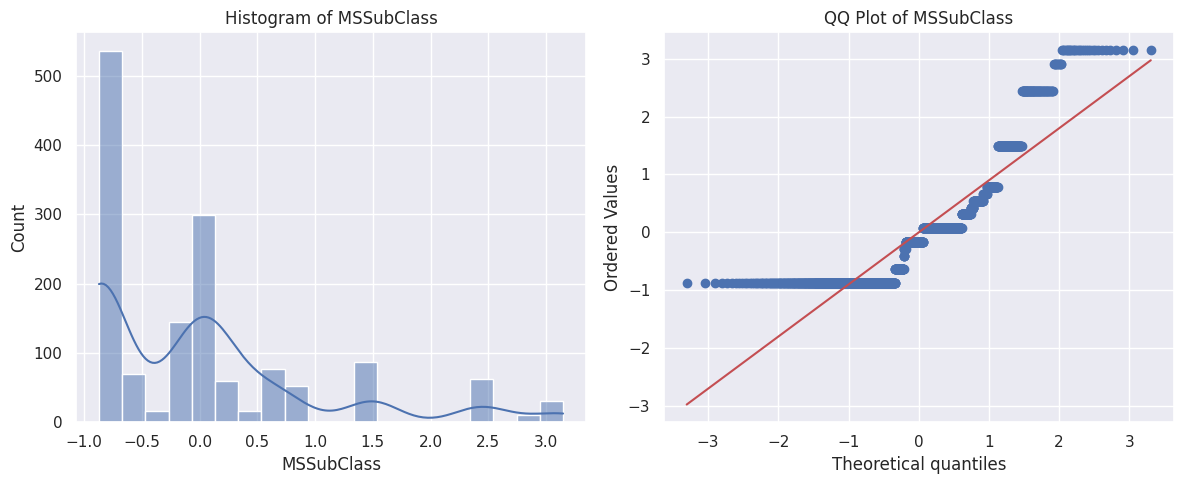

Column: LotFrontage
Shapiro-Wilk Statistic: 0.8507, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


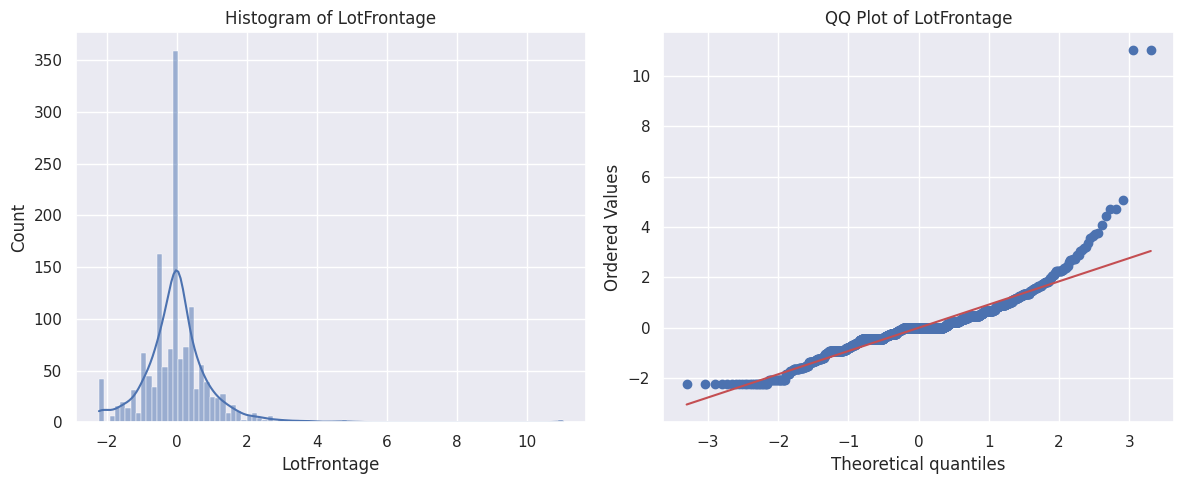

Column: LotArea
Shapiro-Wilk Statistic: 0.3511, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


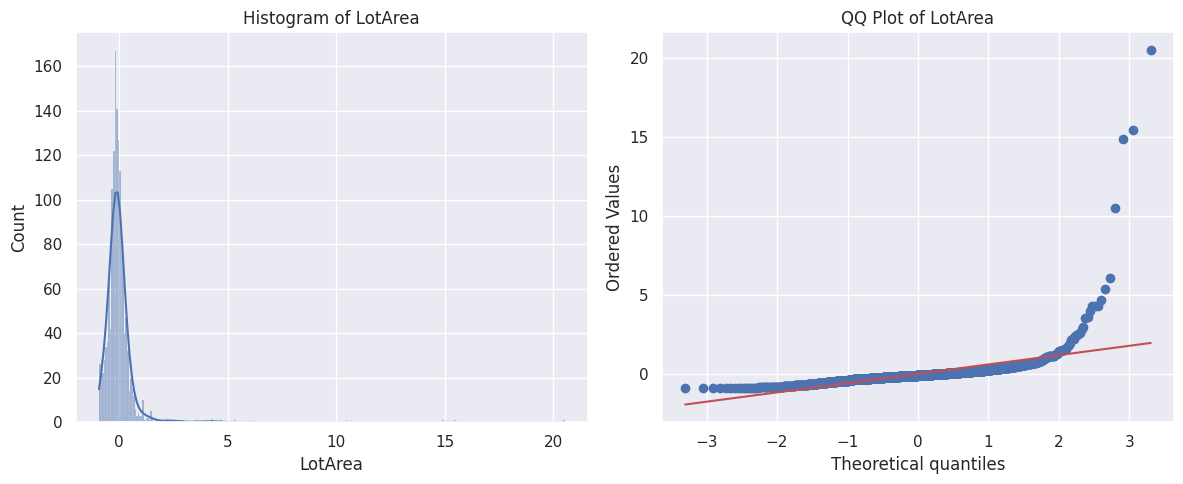

Column: OverallQual
Shapiro-Wilk Statistic: 0.9481, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


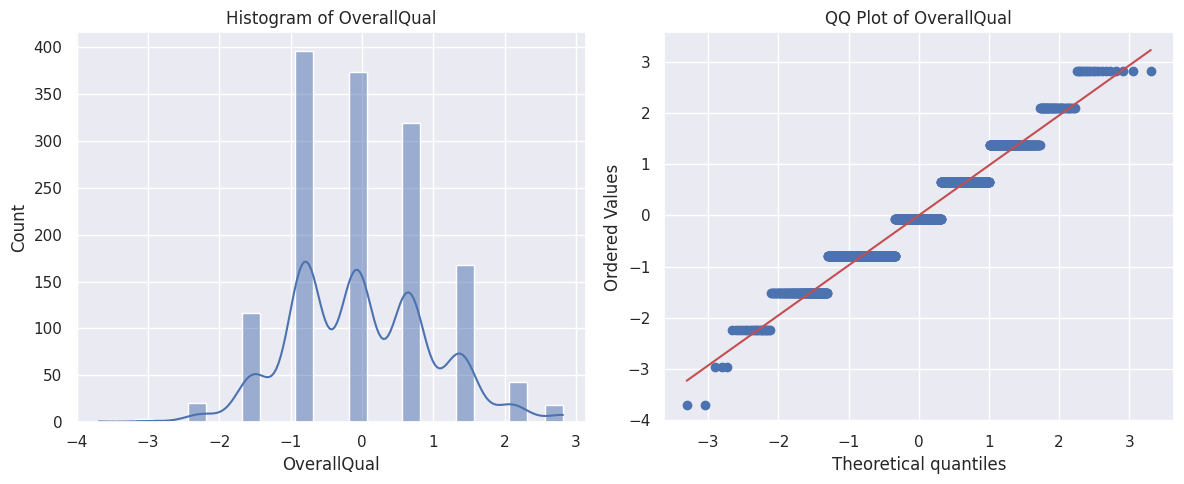

Column: OverallCond
Shapiro-Wilk Statistic: 0.8291, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


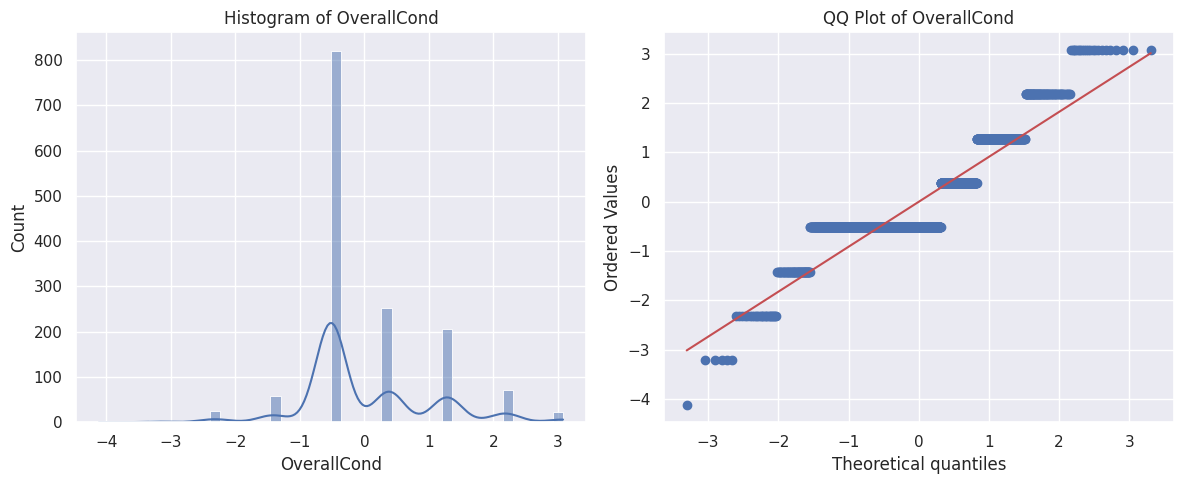

Column: YearBuilt
Shapiro-Wilk Statistic: 0.9258, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


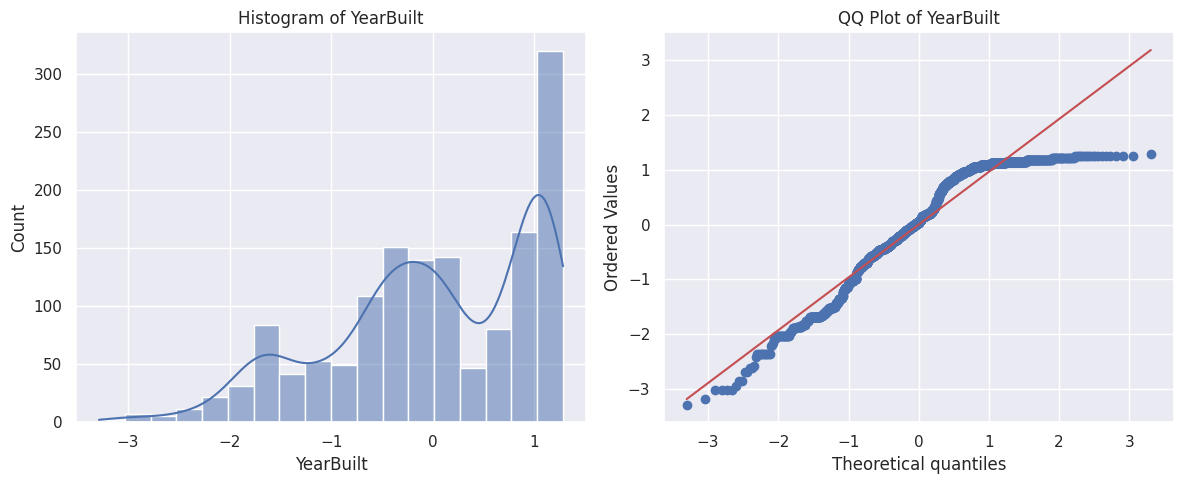

Column: YearRemodAdd
Shapiro-Wilk Statistic: 0.8629, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


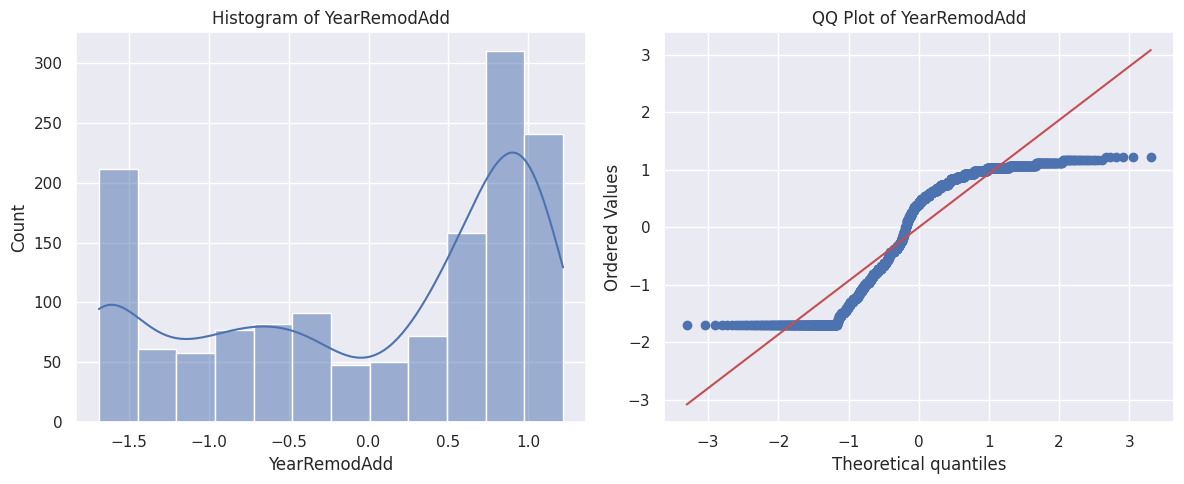

Column: MasVnrArea
Shapiro-Wilk Statistic: 0.6378, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


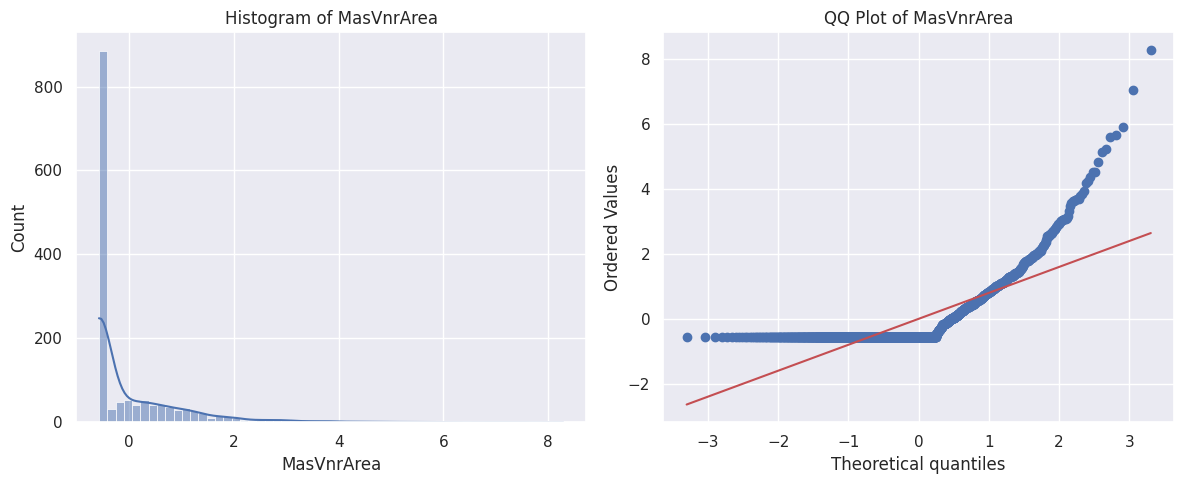

Column: BsmtFinSF1
Shapiro-Wilk Statistic: 0.8481, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


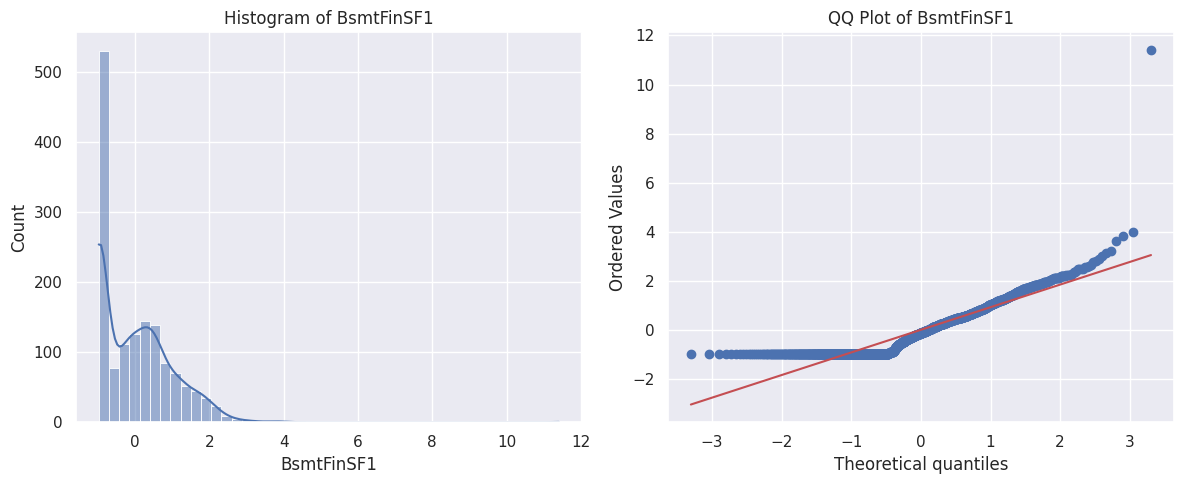

Column: BsmtFinSF2
Shapiro-Wilk Statistic: 0.3274, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


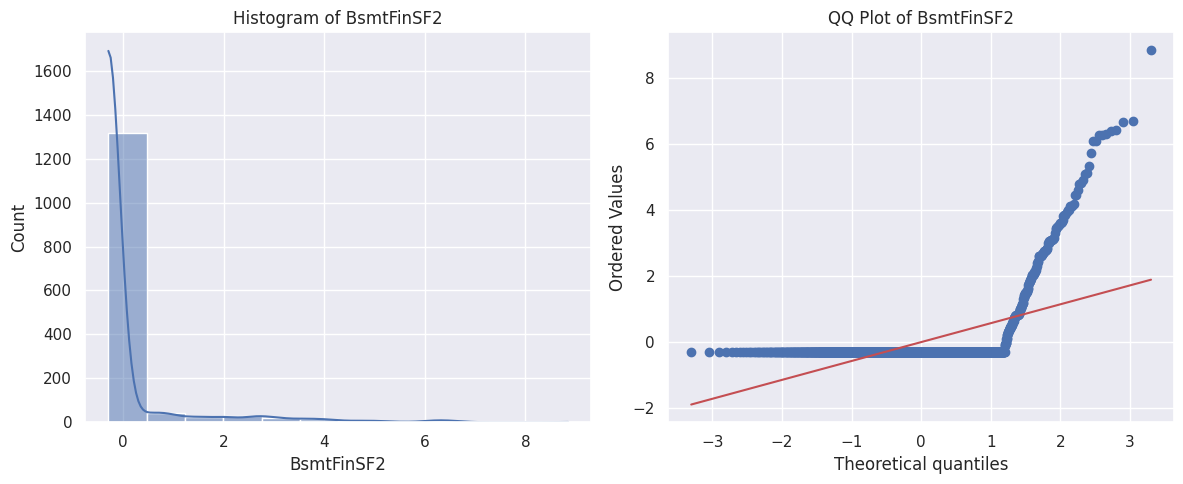

Column: BsmtUnfSF
Shapiro-Wilk Statistic: 0.9305, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


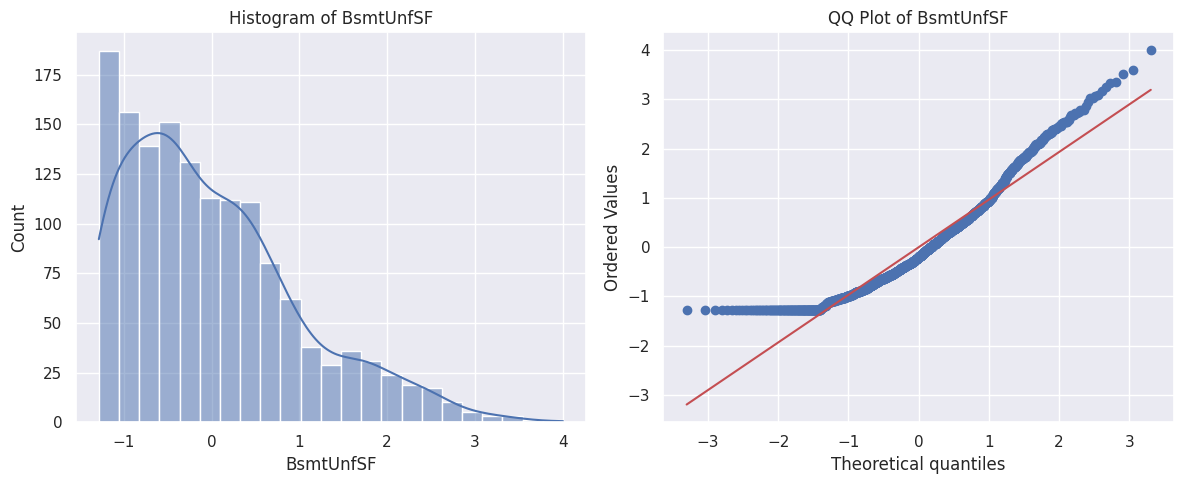

Column: TotalBsmtSF
Shapiro-Wilk Statistic: 0.9170, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


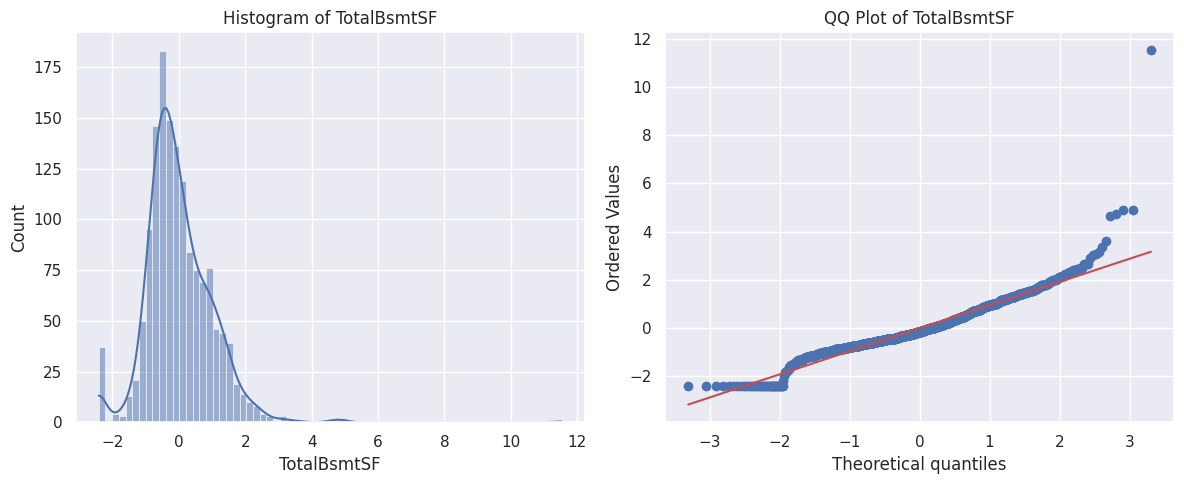

Column: 1stFlrSF
Shapiro-Wilk Statistic: 0.9270, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


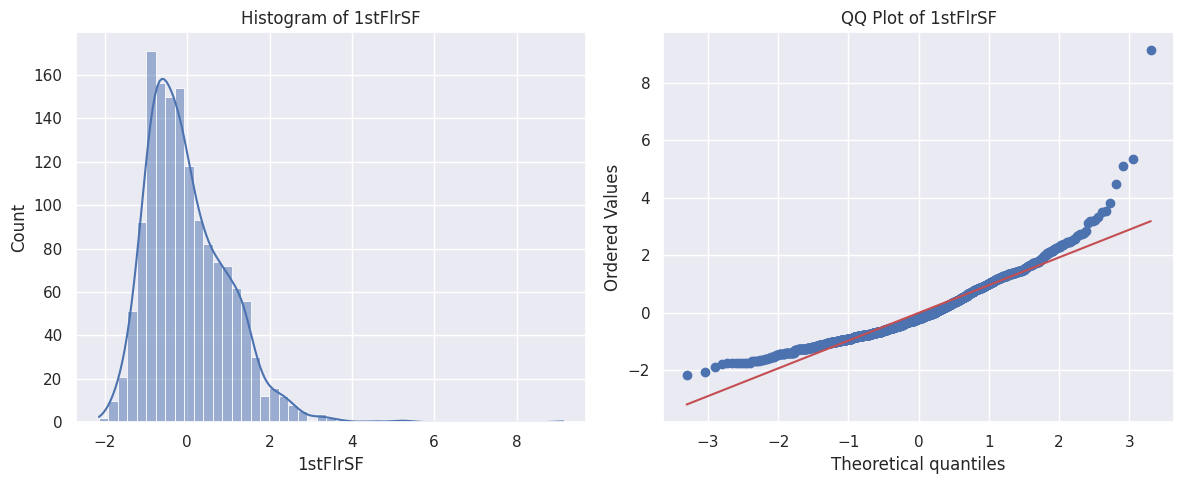

Column: 2ndFlrSF
Shapiro-Wilk Statistic: 0.7665, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


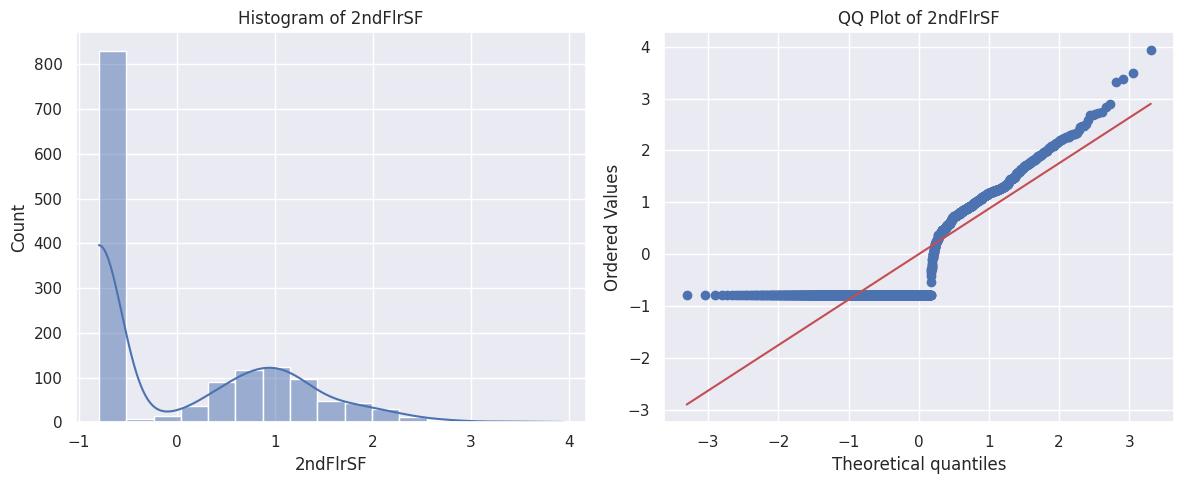

Column: LowQualFinSF
Shapiro-Wilk Statistic: 0.0980, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


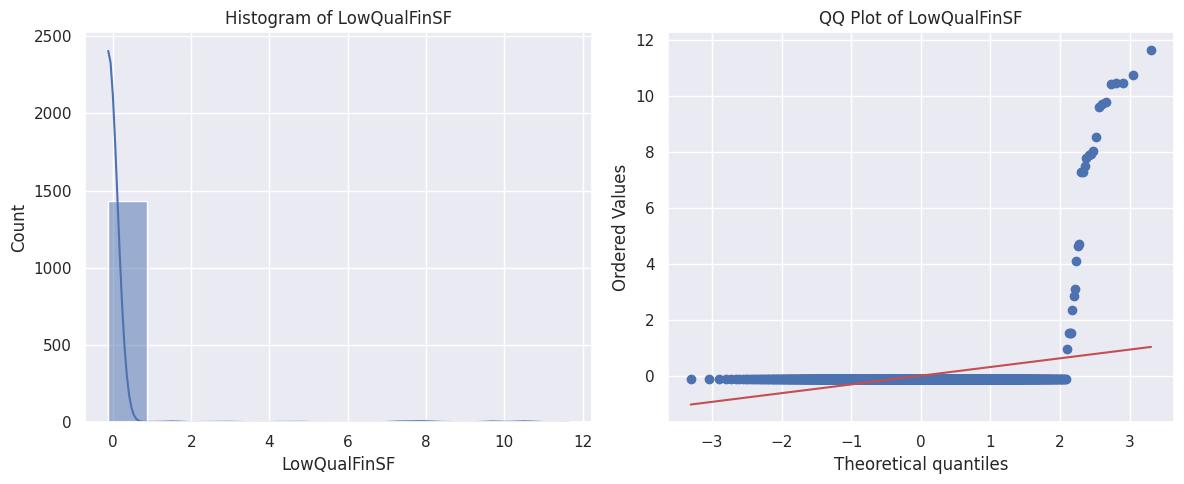

Column: GrLivArea
Shapiro-Wilk Statistic: 0.9280, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


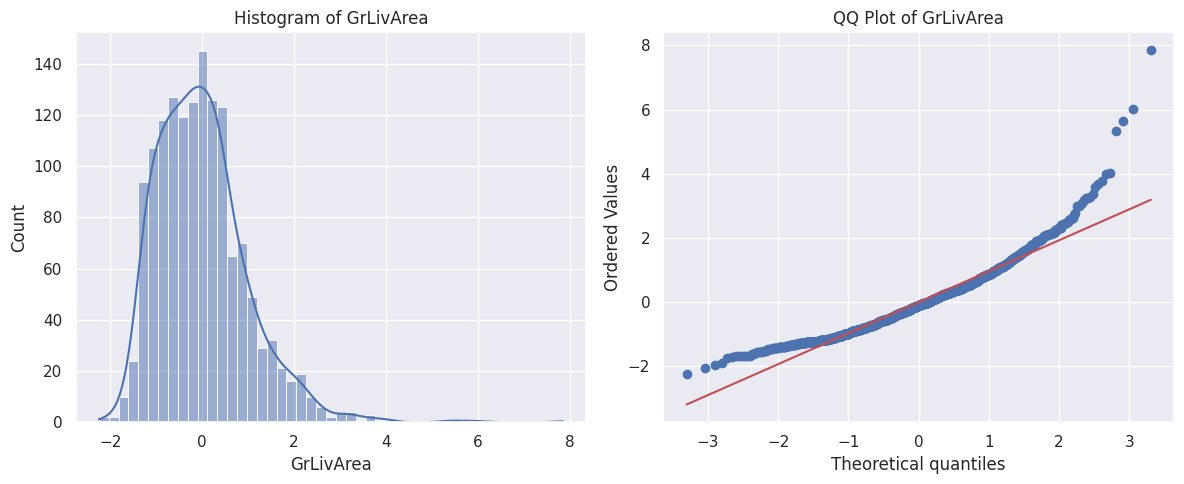

Column: BsmtFullBath
Shapiro-Wilk Statistic: 0.6584, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


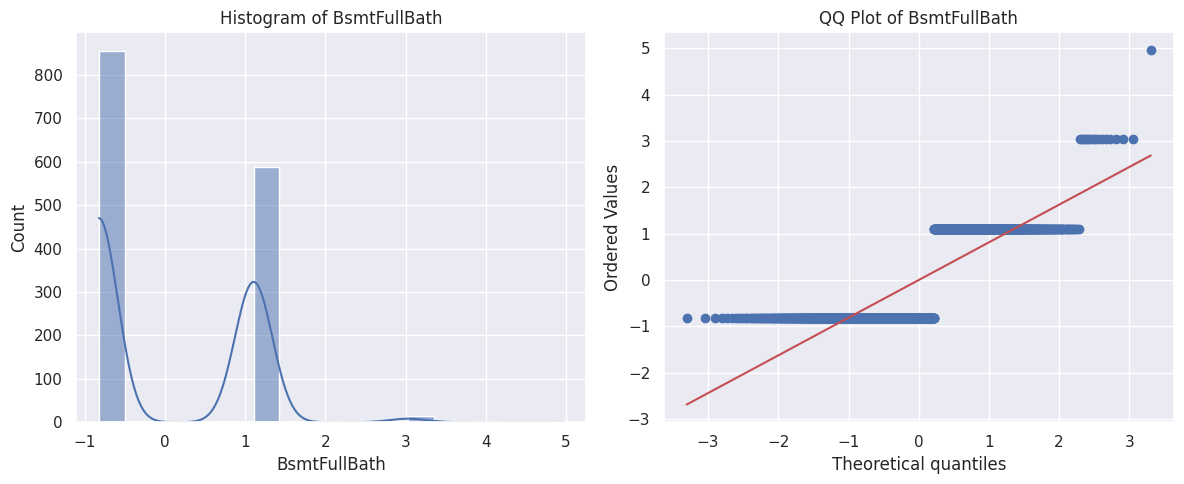

Column: BsmtHalfBath
Shapiro-Wilk Statistic: 0.2430, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


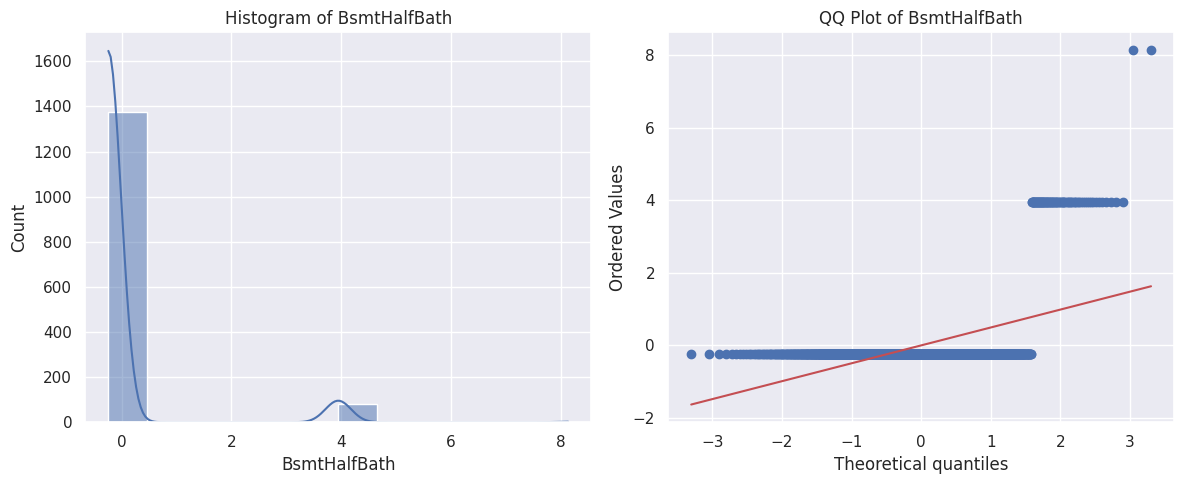

Column: FullBath
Shapiro-Wilk Statistic: 0.7194, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


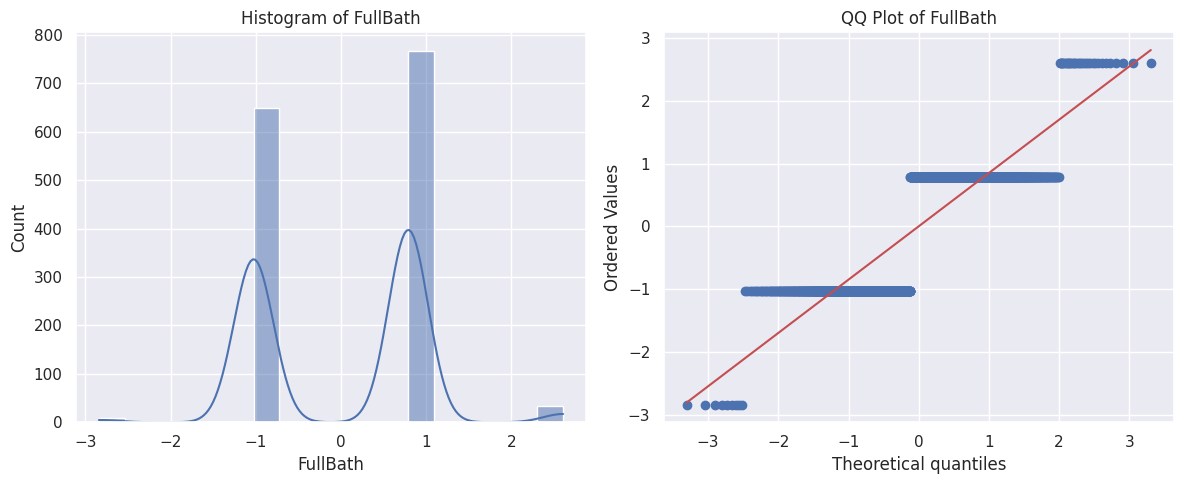

Column: HalfBath
Shapiro-Wilk Statistic: 0.6378, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


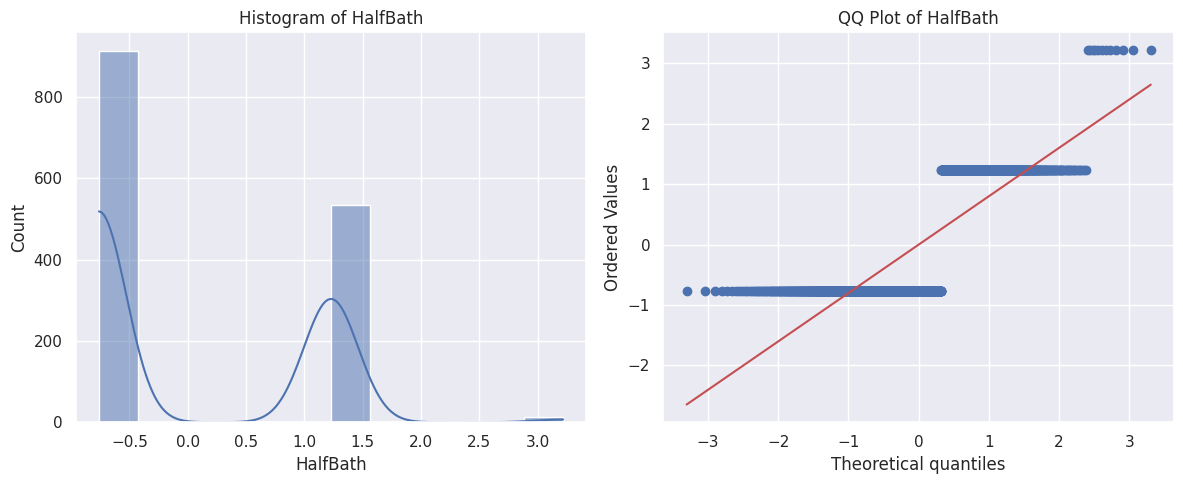

Column: BedroomAbvGr
Shapiro-Wilk Statistic: 0.8500, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


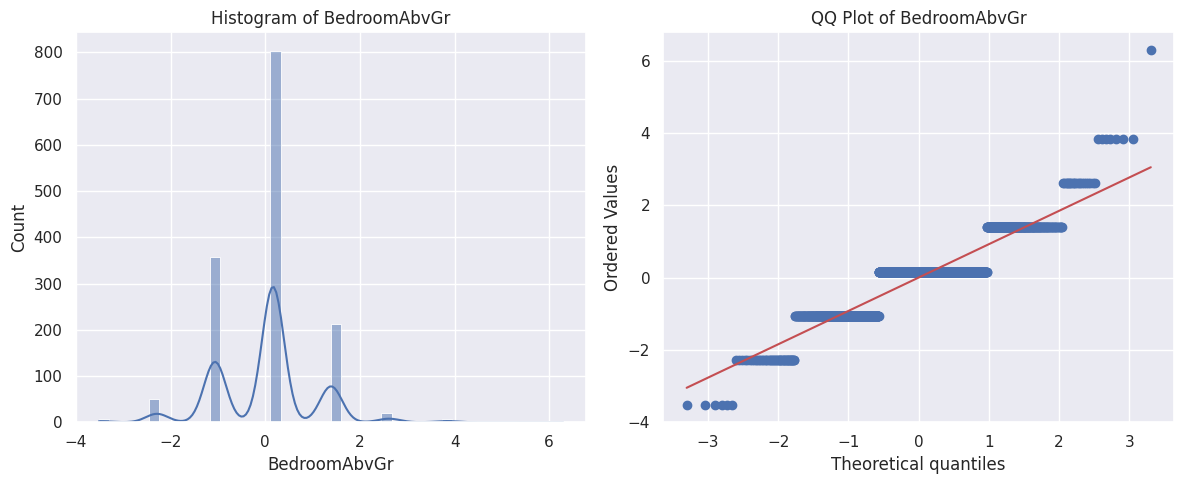

Column: KitchenAbvGr
Shapiro-Wilk Statistic: 0.2199, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


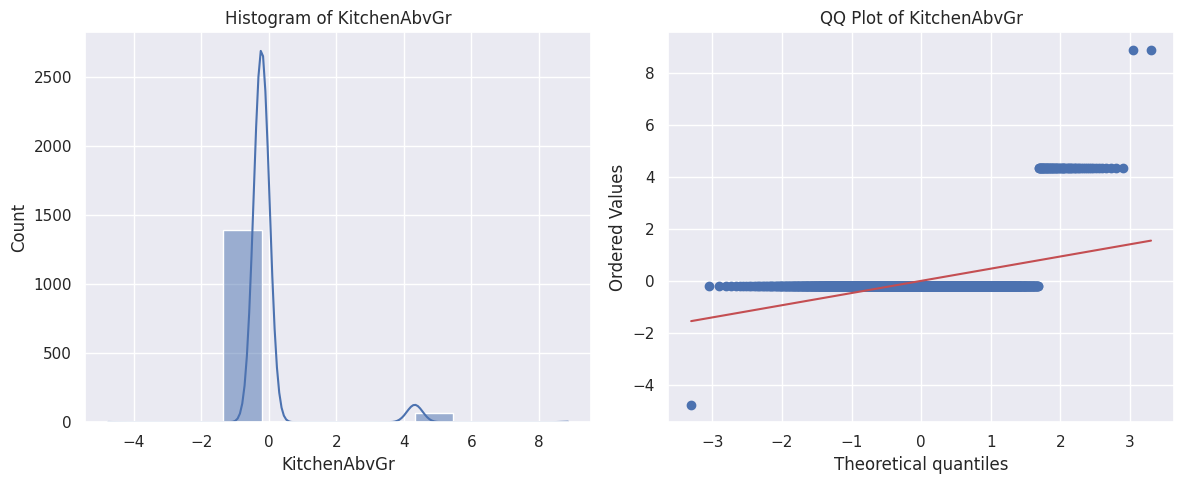

Column: TotRmsAbvGrd
Shapiro-Wilk Statistic: 0.9423, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


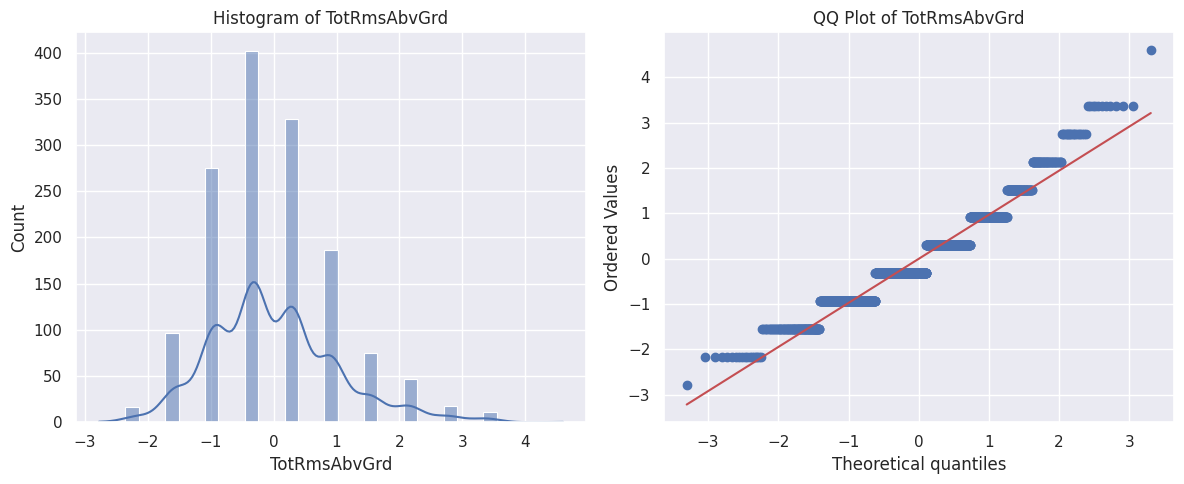

Column: Fireplaces
Shapiro-Wilk Statistic: 0.7553, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


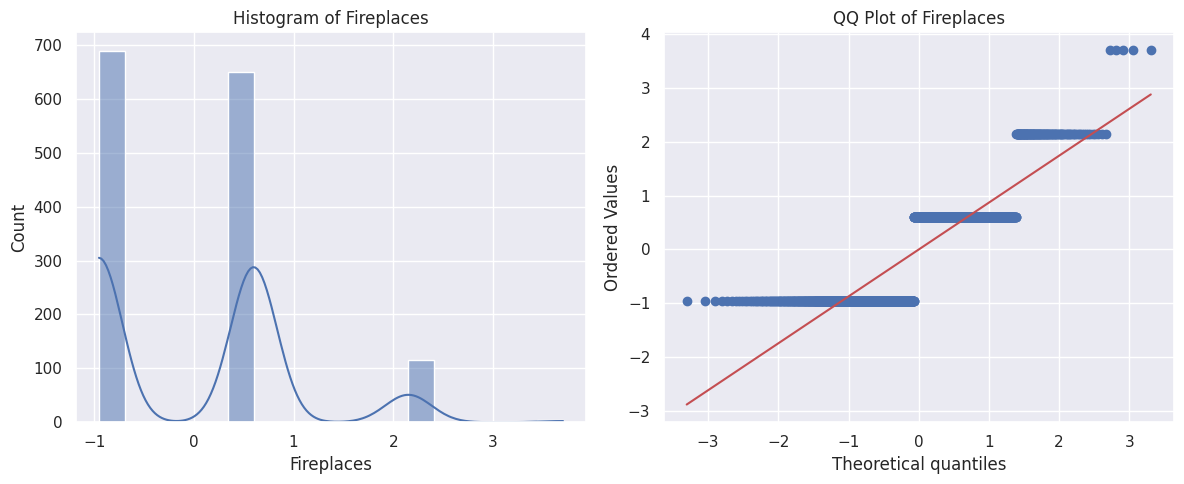

Column: GarageCars
Shapiro-Wilk Statistic: 0.8355, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


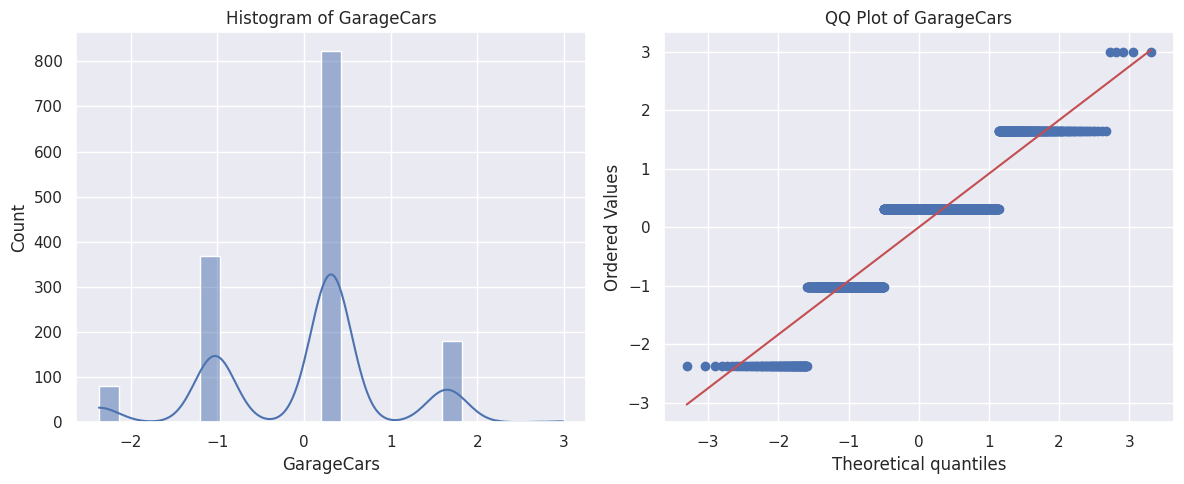

Column: GarageArea
Shapiro-Wilk Statistic: 0.9753, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


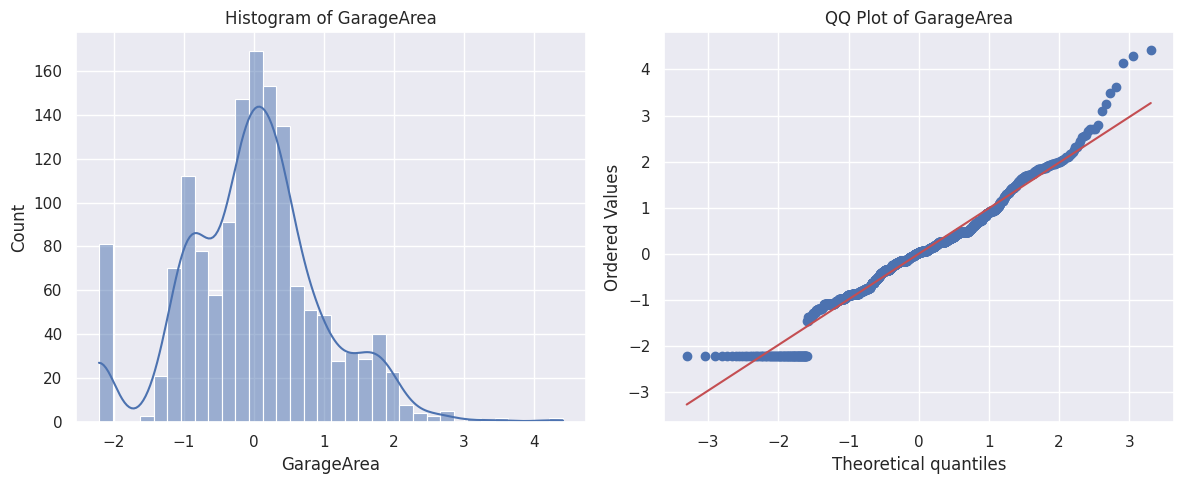

Column: WoodDeckSF
Shapiro-Wilk Statistic: 0.7683, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


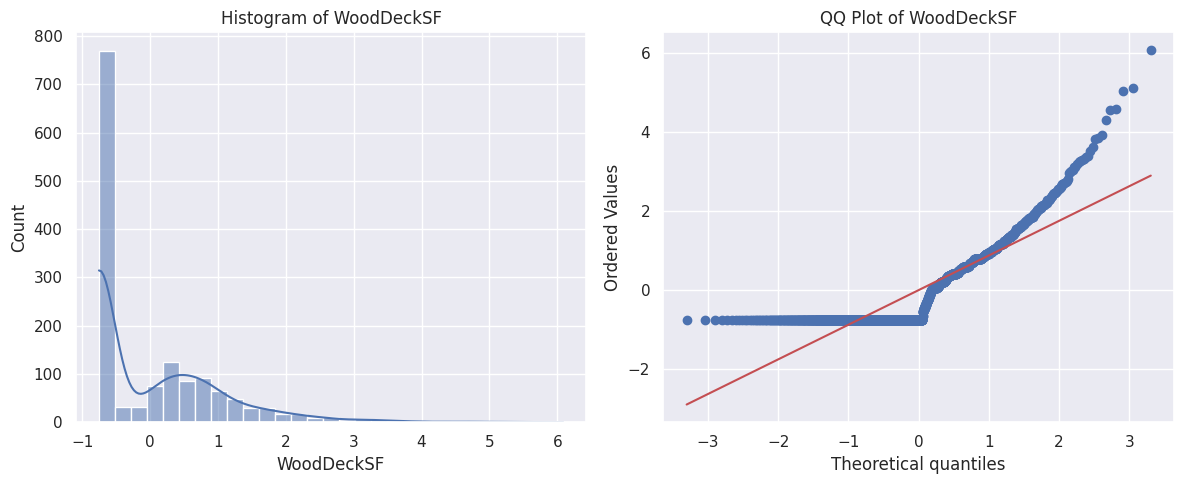

Column: OpenPorchSF
Shapiro-Wilk Statistic: 0.7274, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


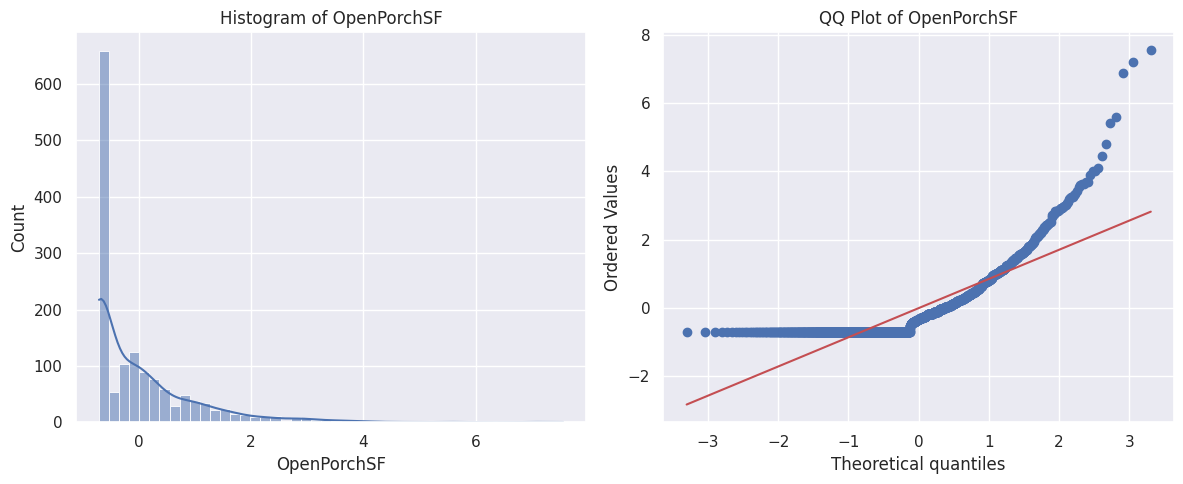

Column: EnclosedPorch
Shapiro-Wilk Statistic: 0.4146, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


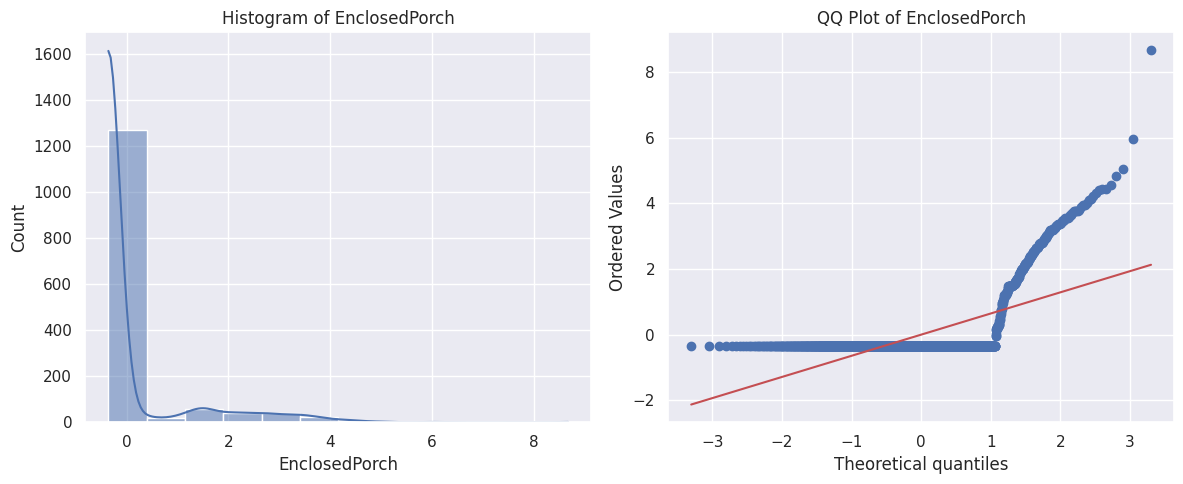

Column: 3SsnPorch
Shapiro-Wilk Statistic: 0.0950, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


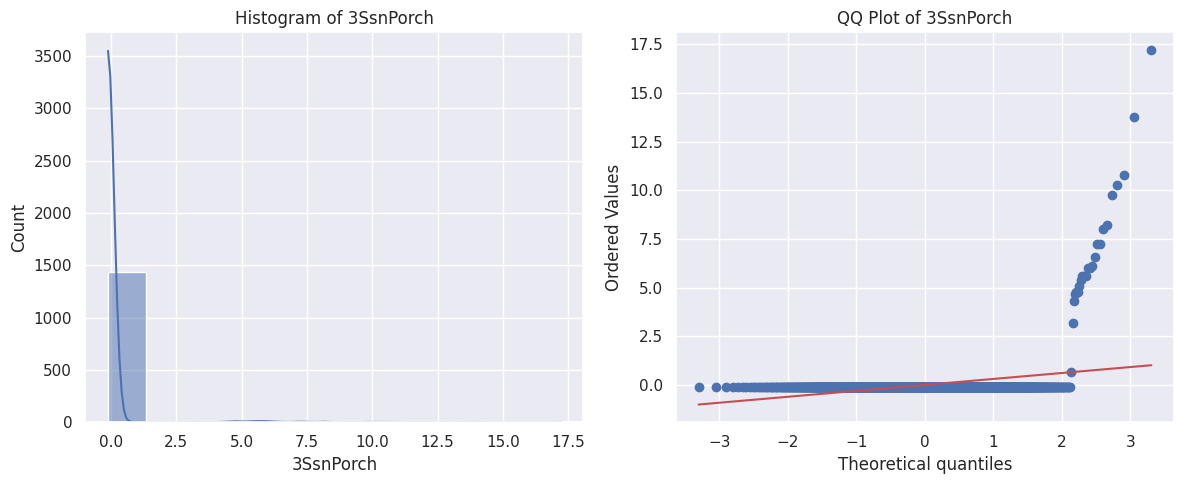

Column: ScreenPorch
Shapiro-Wilk Statistic: 0.2983, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


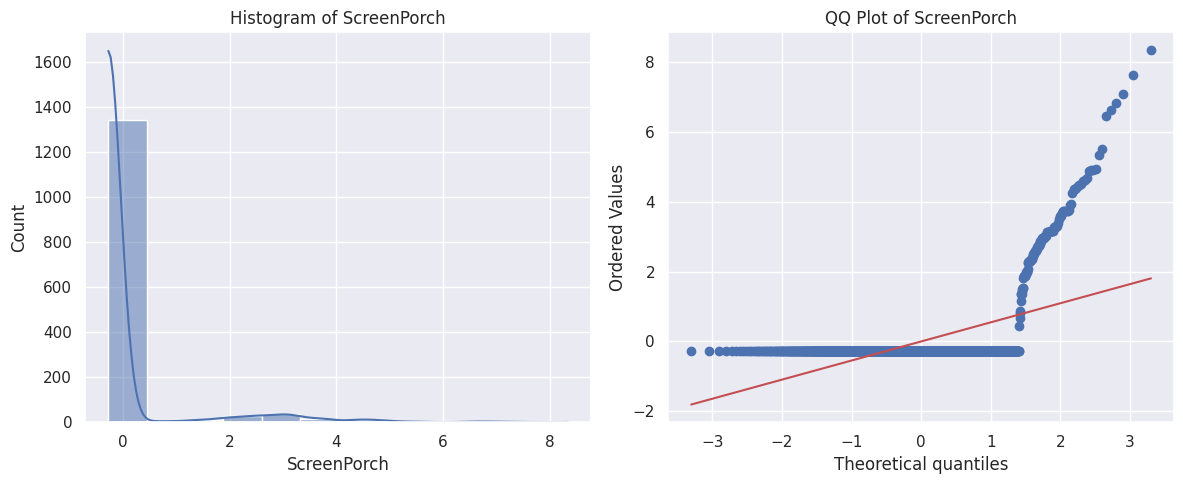

Column: PoolArea
Shapiro-Wilk Statistic: 0.0412, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


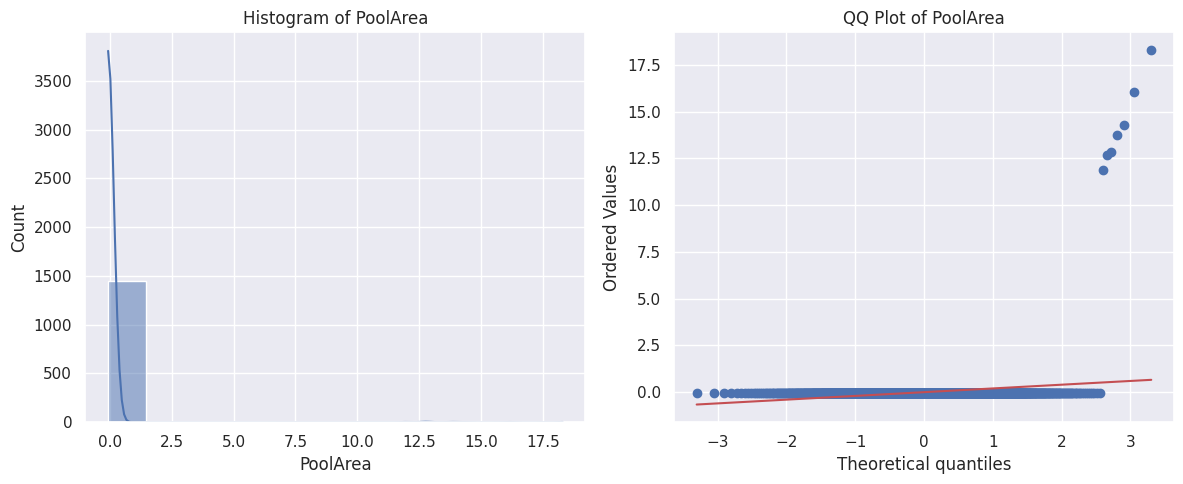

Column: MiscVal
Shapiro-Wilk Statistic: 0.0583, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


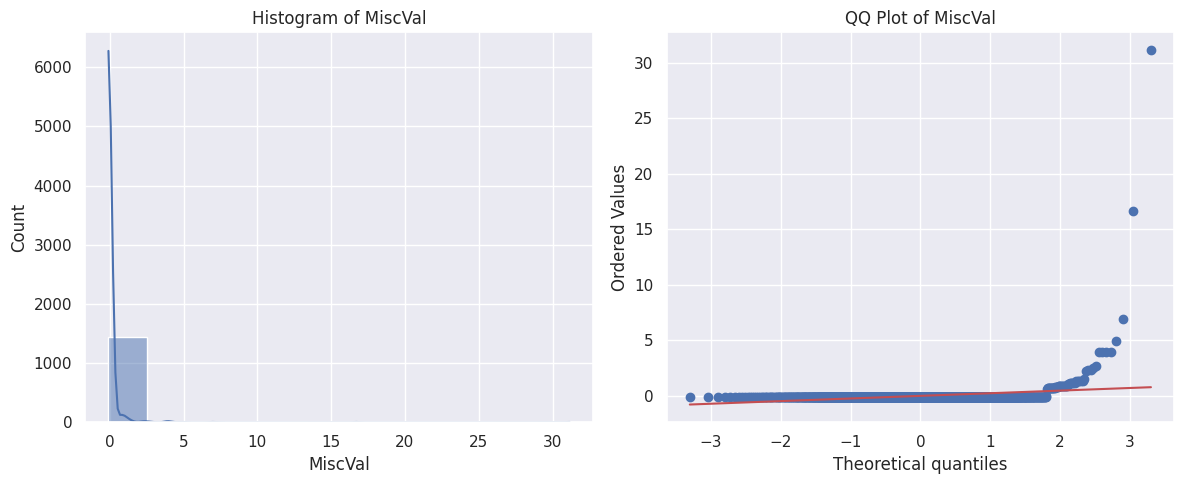

Column: MoSold
Shapiro-Wilk Statistic: 0.9688, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


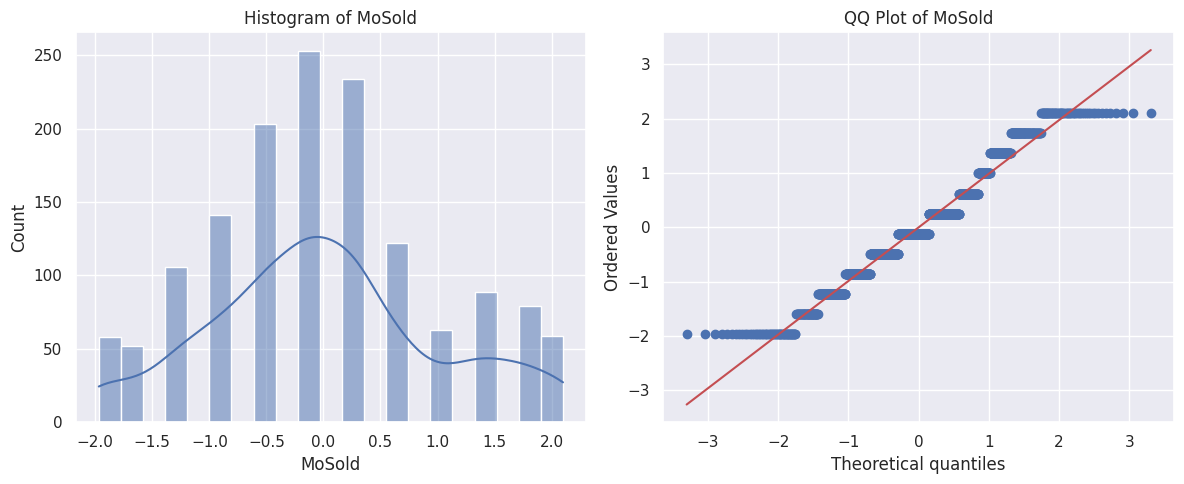

Column: YrSold
Shapiro-Wilk Statistic: 0.8970, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


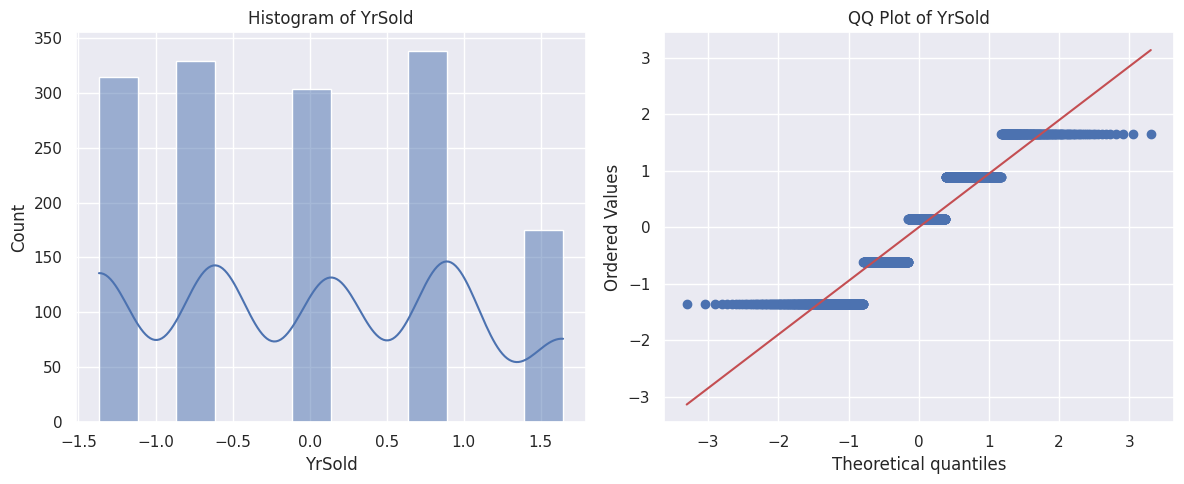

Column: SalePrice
Shapiro-Wilk Statistic: 0.8697, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


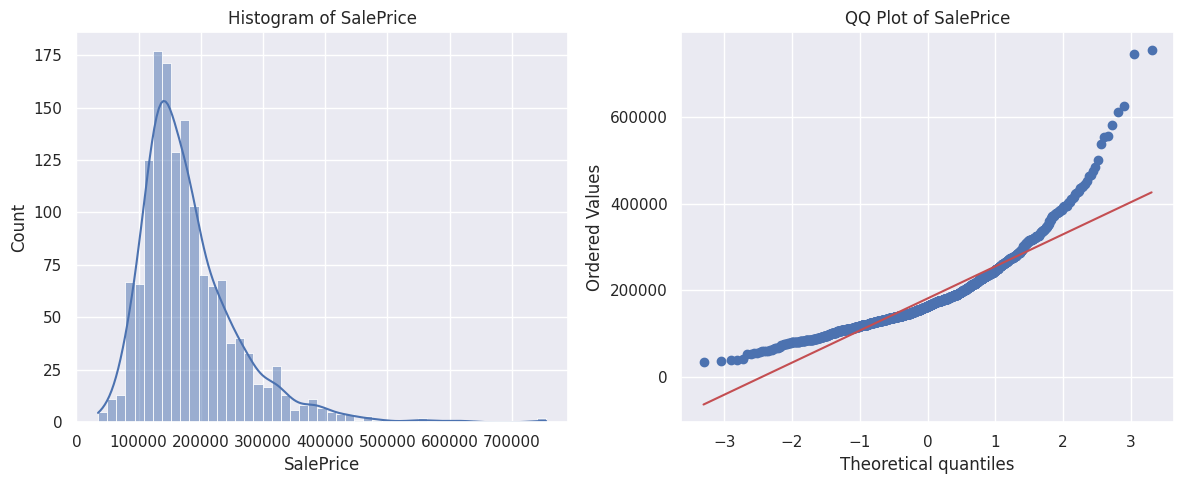

In [110]:
# Identify numerical columns
numerical_cols = final_df.select_dtypes(include=np.number).columns

# Check for normality for each numerical column
for col in numerical_cols:
    # Shapiro-Wilk test for normality
    # p-value < 0.05 suggests the data is NOT normally distributed
    stat, p_value = stats.shapiro(final_df[col])

    alpha = 0.05
    print(f"Column: {col}")
    print(f"Shapiro-Wilk Statistic: {stat:.4f}, P-value: {p_value:.4f}")

    if p_value > alpha:
        print("Conclusion: The data for this column appears to be normally distributed (fail to reject H0)")
    else:
        print("Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)")
    print("-" * 30)

    # Optional: Visualize the distribution using a histogram and QQ plot
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(final_df[col], kde=True)
    plt.title(f'Histogram of {col}')

    # QQ Plot
    plt.subplot(1, 2, 2)
    stats.probplot(final_df[col], dist="norm", plot=plt)
    plt.title(f'QQ Plot of {col}')

    plt.tight_layout()
    plt.show()

Number of outlier rows identified: 439
Shape after removing outliers: (1020, 175)


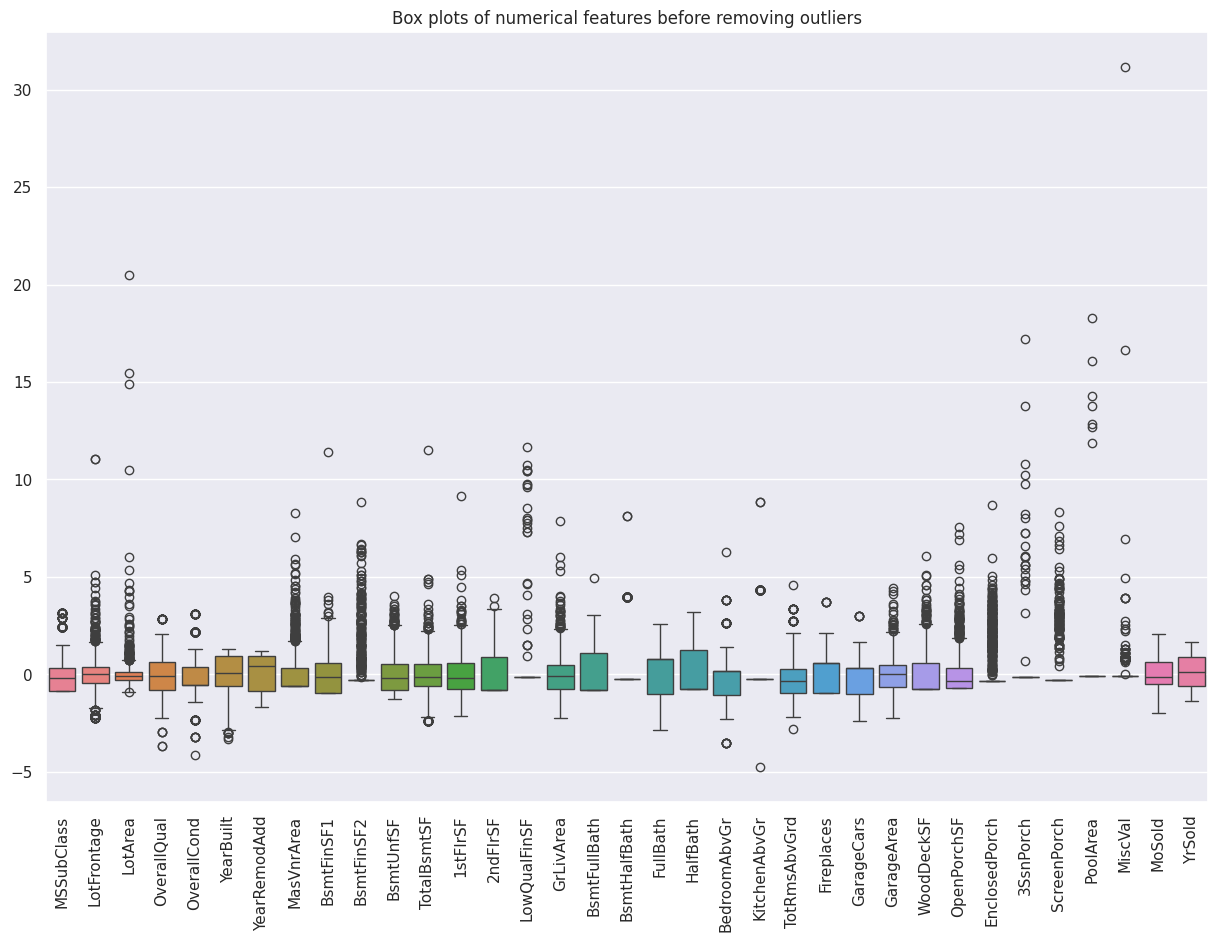

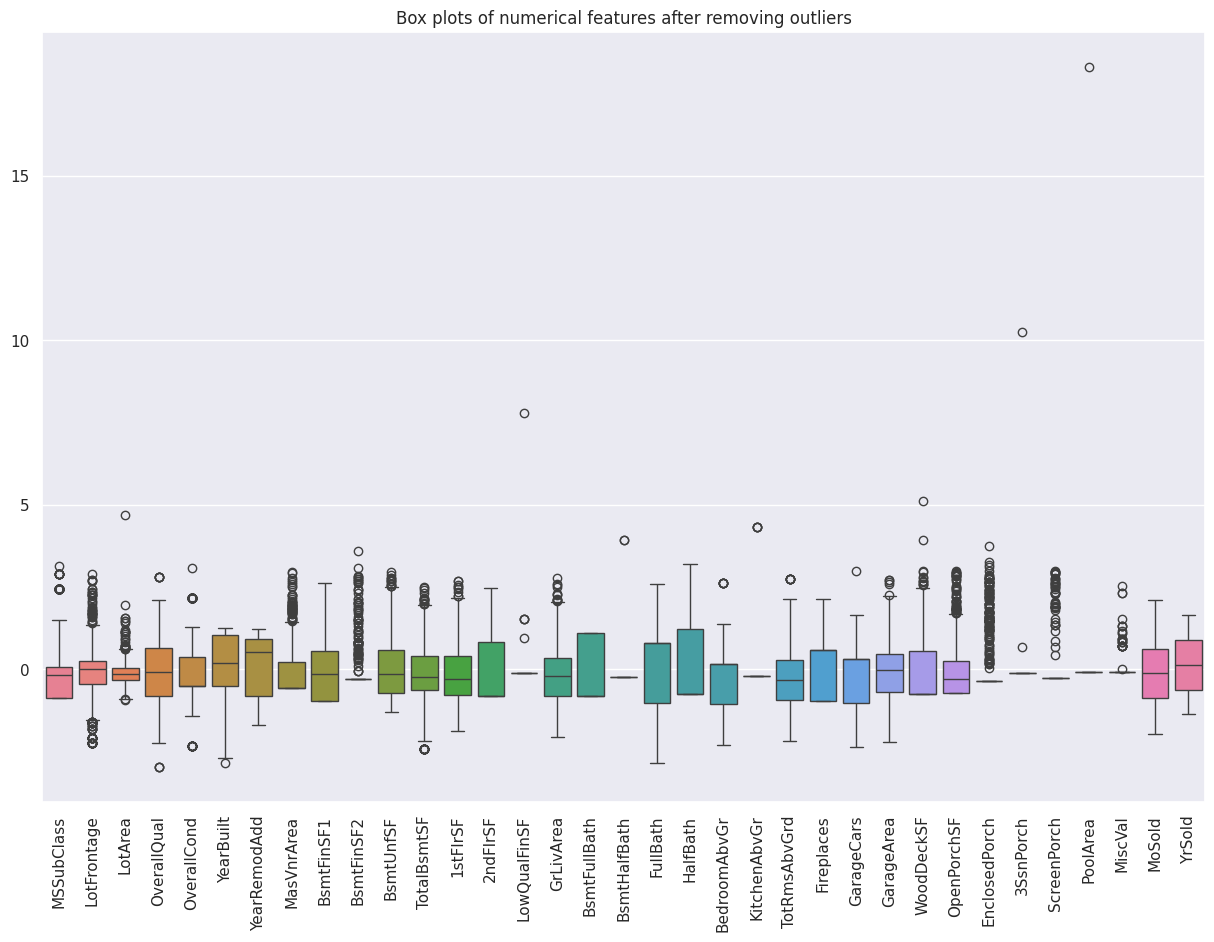

In [111]:
# Use Z-score to detect outliers in numerical features
z_scores = np.abs(stats.zscore(final_df[numerical_features]))
outlier_threshold = 3 # A common threshold

# Identify rows with outliers
outlier_rows = np.where(z_scores > outlier_threshold)[0]

print(f"Number of outlier rows identified: {len(np.unique(outlier_rows))}")

# Option 1: Remove outliers (simplest approach)
df_cleaned = final_df.drop(np.unique(outlier_rows)).reset_index(drop=True)
print(f"Shape after removing outliers: {df_cleaned.shape}")

# Option 2: Cap outliers (replace values beyond a certain threshold)
# we can cap values at the threshold or the mean/median
# for col in numerical_features:
#     upper_limit = final_df[col].mean() + outlier_threshold * final_df[col].std()
#     lower_limit = final_df[col].mean() - outlier_threshold * final_df[col].std()
#     final_df[col] = np.where(
#         final_df[col] > upper_limit,
#         upper_limit,
#         np.where(
#             final_df[col] < lower_limit,
#             lower_limit,
#             final_df[col]
#         )
#     )
#print("\nOutliers have been capped in the original dataframe.")

# we can visualize the data before and after handling outliers to see the effect
# For example, using box plots for numerical features

plt.figure(figsize=(15, 10))
sns.boxplot(data=final_df[numerical_features])
plt.title('Box plots of numerical features before removing outliers')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(15, 10))
sns.boxplot(data=df_cleaned[numerical_features])
plt.title('Box plots of numerical features after removing outliers')
plt.xticks(rotation=90)
plt.show()



In [112]:
final_df=df_cleaned
final_df.shape

(1020, 175)

### 2.1	Creating Interaction Features: Create meaningful interaction features that may help improve model performance

In [113]:
categorical_features1 = final_df.select_dtypes(include=[np.object_])
categorical_features

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [114]:
numerical_features1 = final_df.select_dtypes(include=[np.number])
numerical_features1.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [115]:
correlation = numerical_features1.corr()
print(correlation['SalePrice'].sort_values(ascending=False), '\n')

SalePrice        1.000000
OverallQual      0.809200
GrLivArea        0.753833
GarageCars       0.692950
GarageArea       0.674507
FullBath         0.658833
TotalBsmtSF      0.632432
YearBuilt        0.617265
1stFlrSF         0.601706
TotRmsAbvGrd     0.593398
YearRemodAdd     0.558008
Fireplaces       0.424708
MasVnrArea       0.419452
OpenPorchSF      0.411236
LotFrontage      0.396190
BsmtFinSF1       0.372088
LotArea          0.341113
WoodDeckSF       0.325561
2ndFlrSF         0.316843
HalfBath         0.260566
BedroomAbvGr     0.254766
BsmtFullBath     0.241017
BsmtUnfSF        0.211465
3SsnPorch        0.102380
MoSold           0.099609
PoolArea         0.046960
ScreenPorch      0.019156
BsmtHalfBath     0.018903
LowQualFinSF    -0.000401
MSSubClass      -0.032660
KitchenAbvGr    -0.043141
YrSold          -0.050341
MiscVal         -0.070386
BsmtFinSF2      -0.105007
OverallCond     -0.158203
EnclosedPorch   -0.192745
Name: SalePrice, dtype: float64 



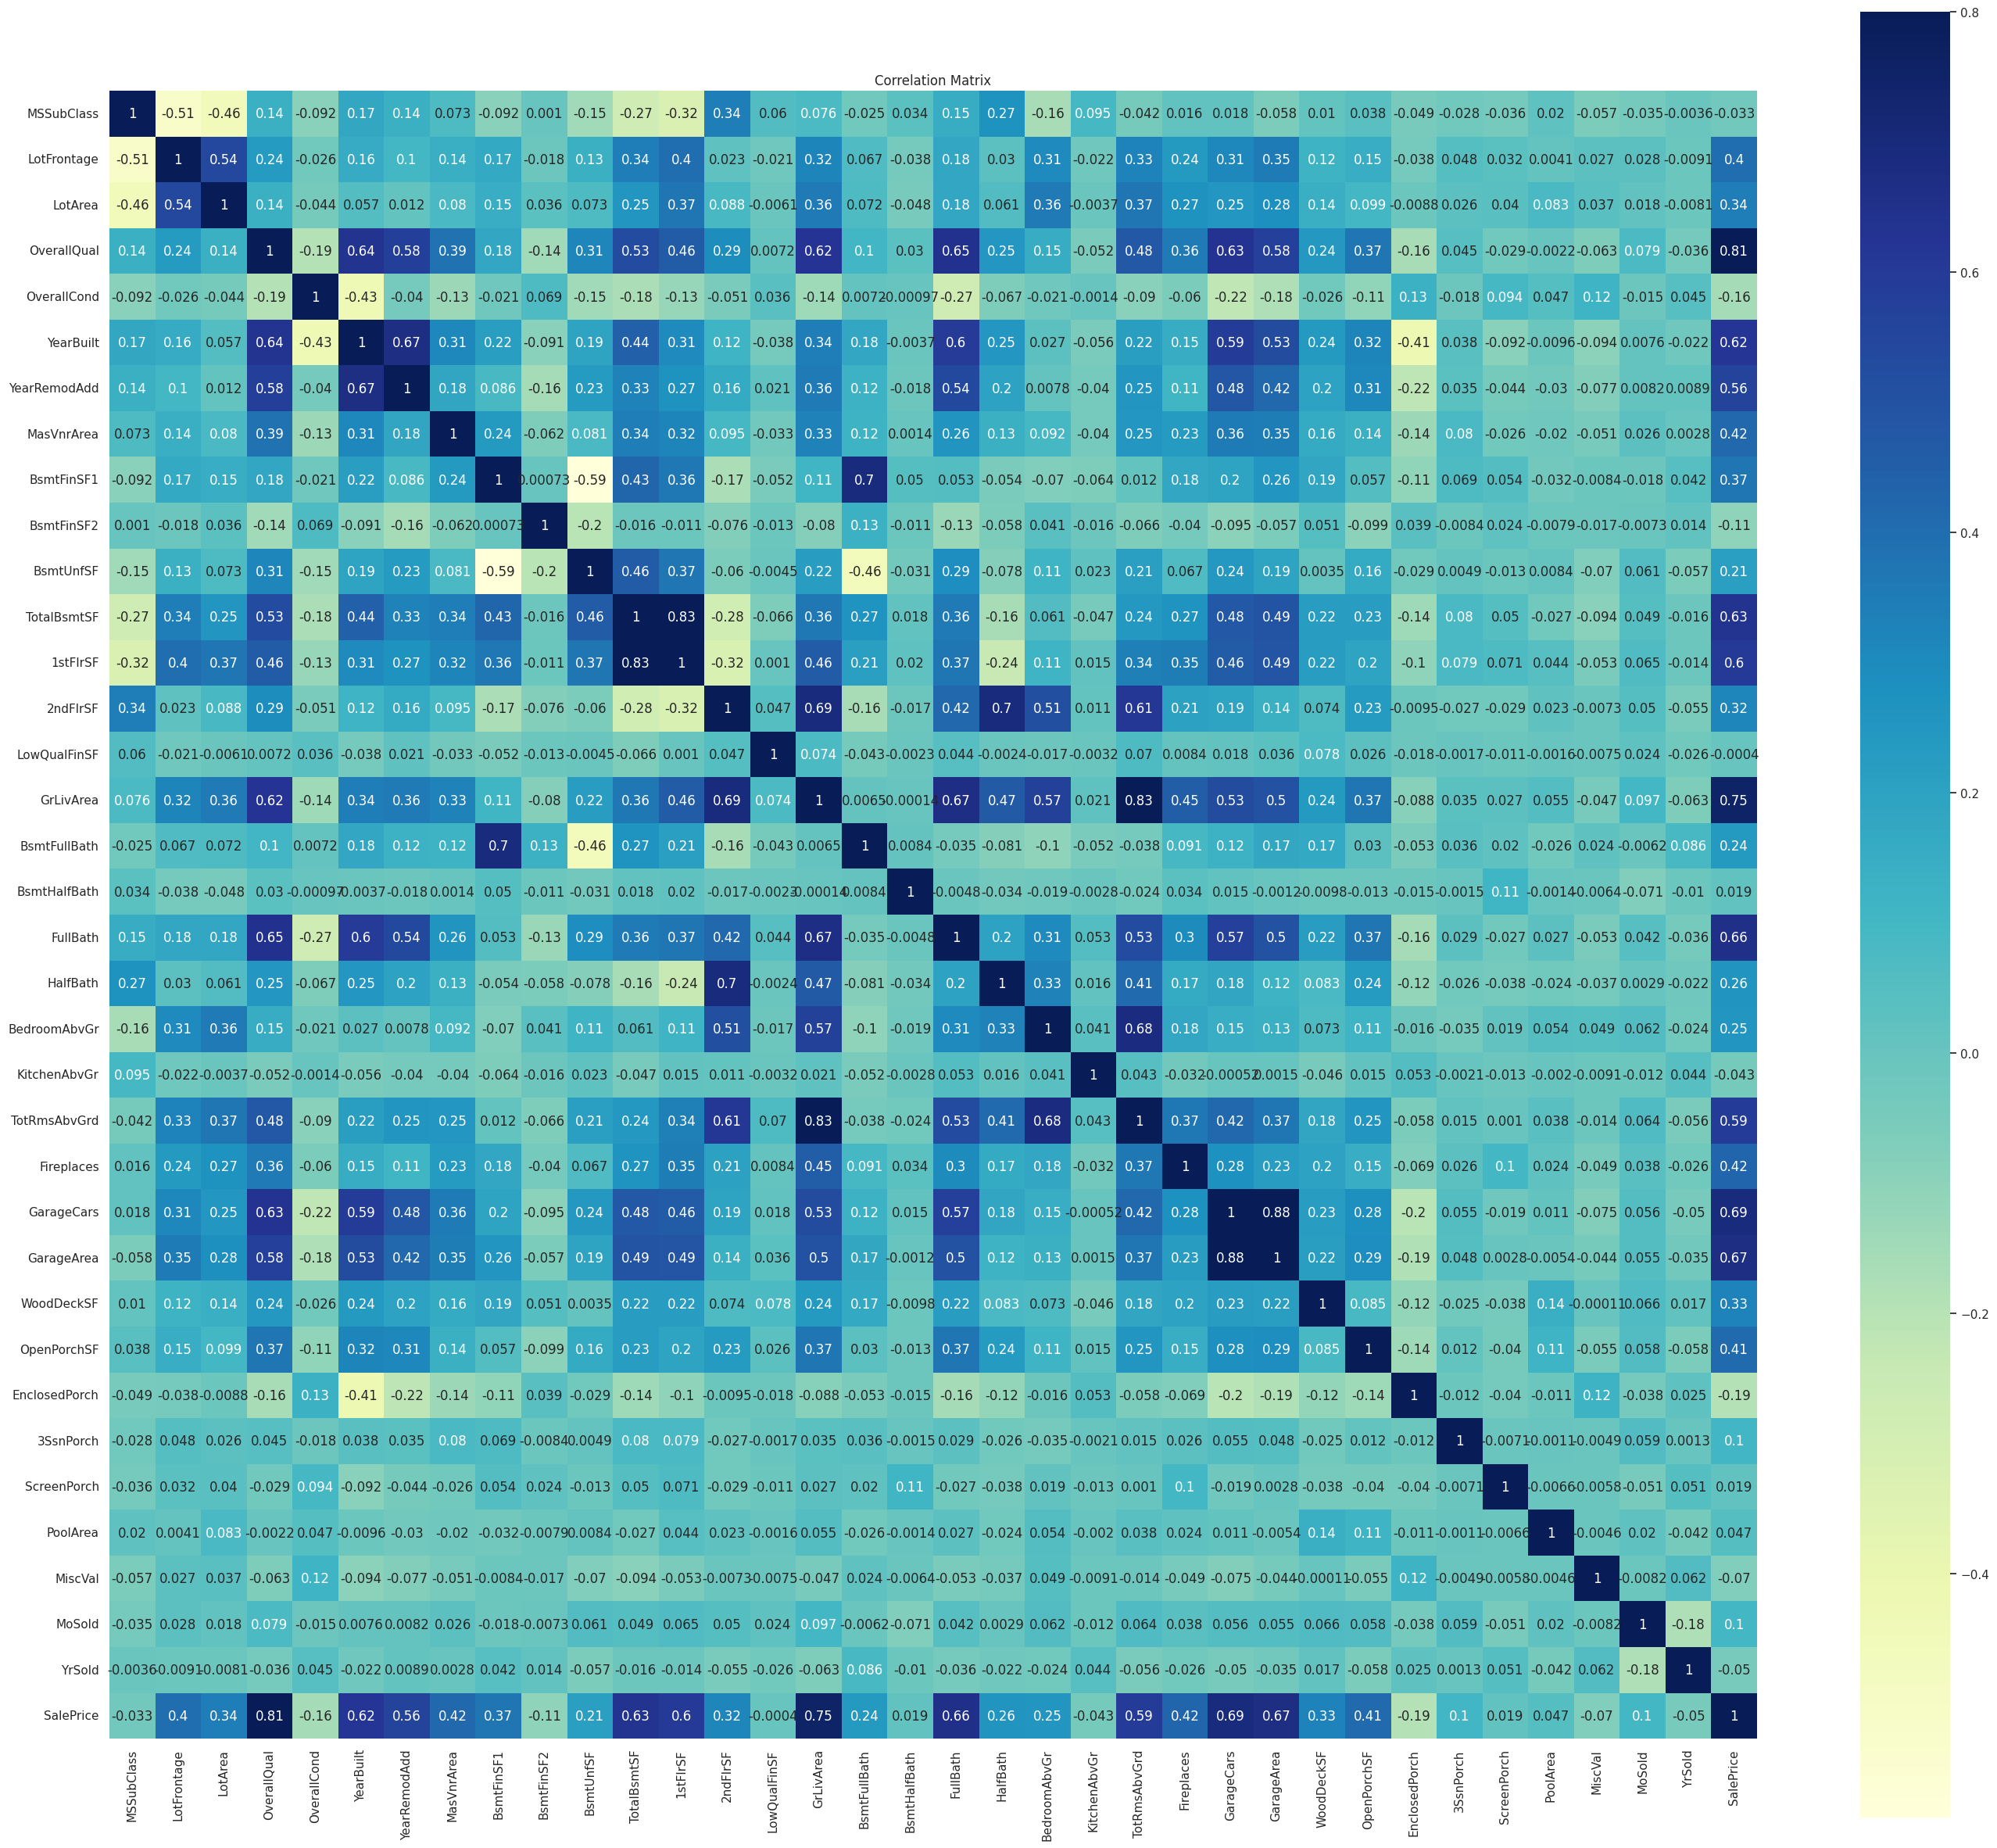

In [116]:
f, ax = plt.subplots(figsize=(34, 30))
plt.title('Correlation Matrix')
sns.heatmap(correlation, vmax=.8, square=True, cmap="YlGnBu", annot=True)
plt.show()

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'FullBath', 'TotalBsmtSF', 'YearBuilt', '1stFlrSF', 'TotRmsAbvGrd',
       'YearRemodAdd', 'Fireplaces', 'MasVnrArea', 'OpenPorchSF',
       'LotFrontage'],
      dtype='object')


<Axes: >

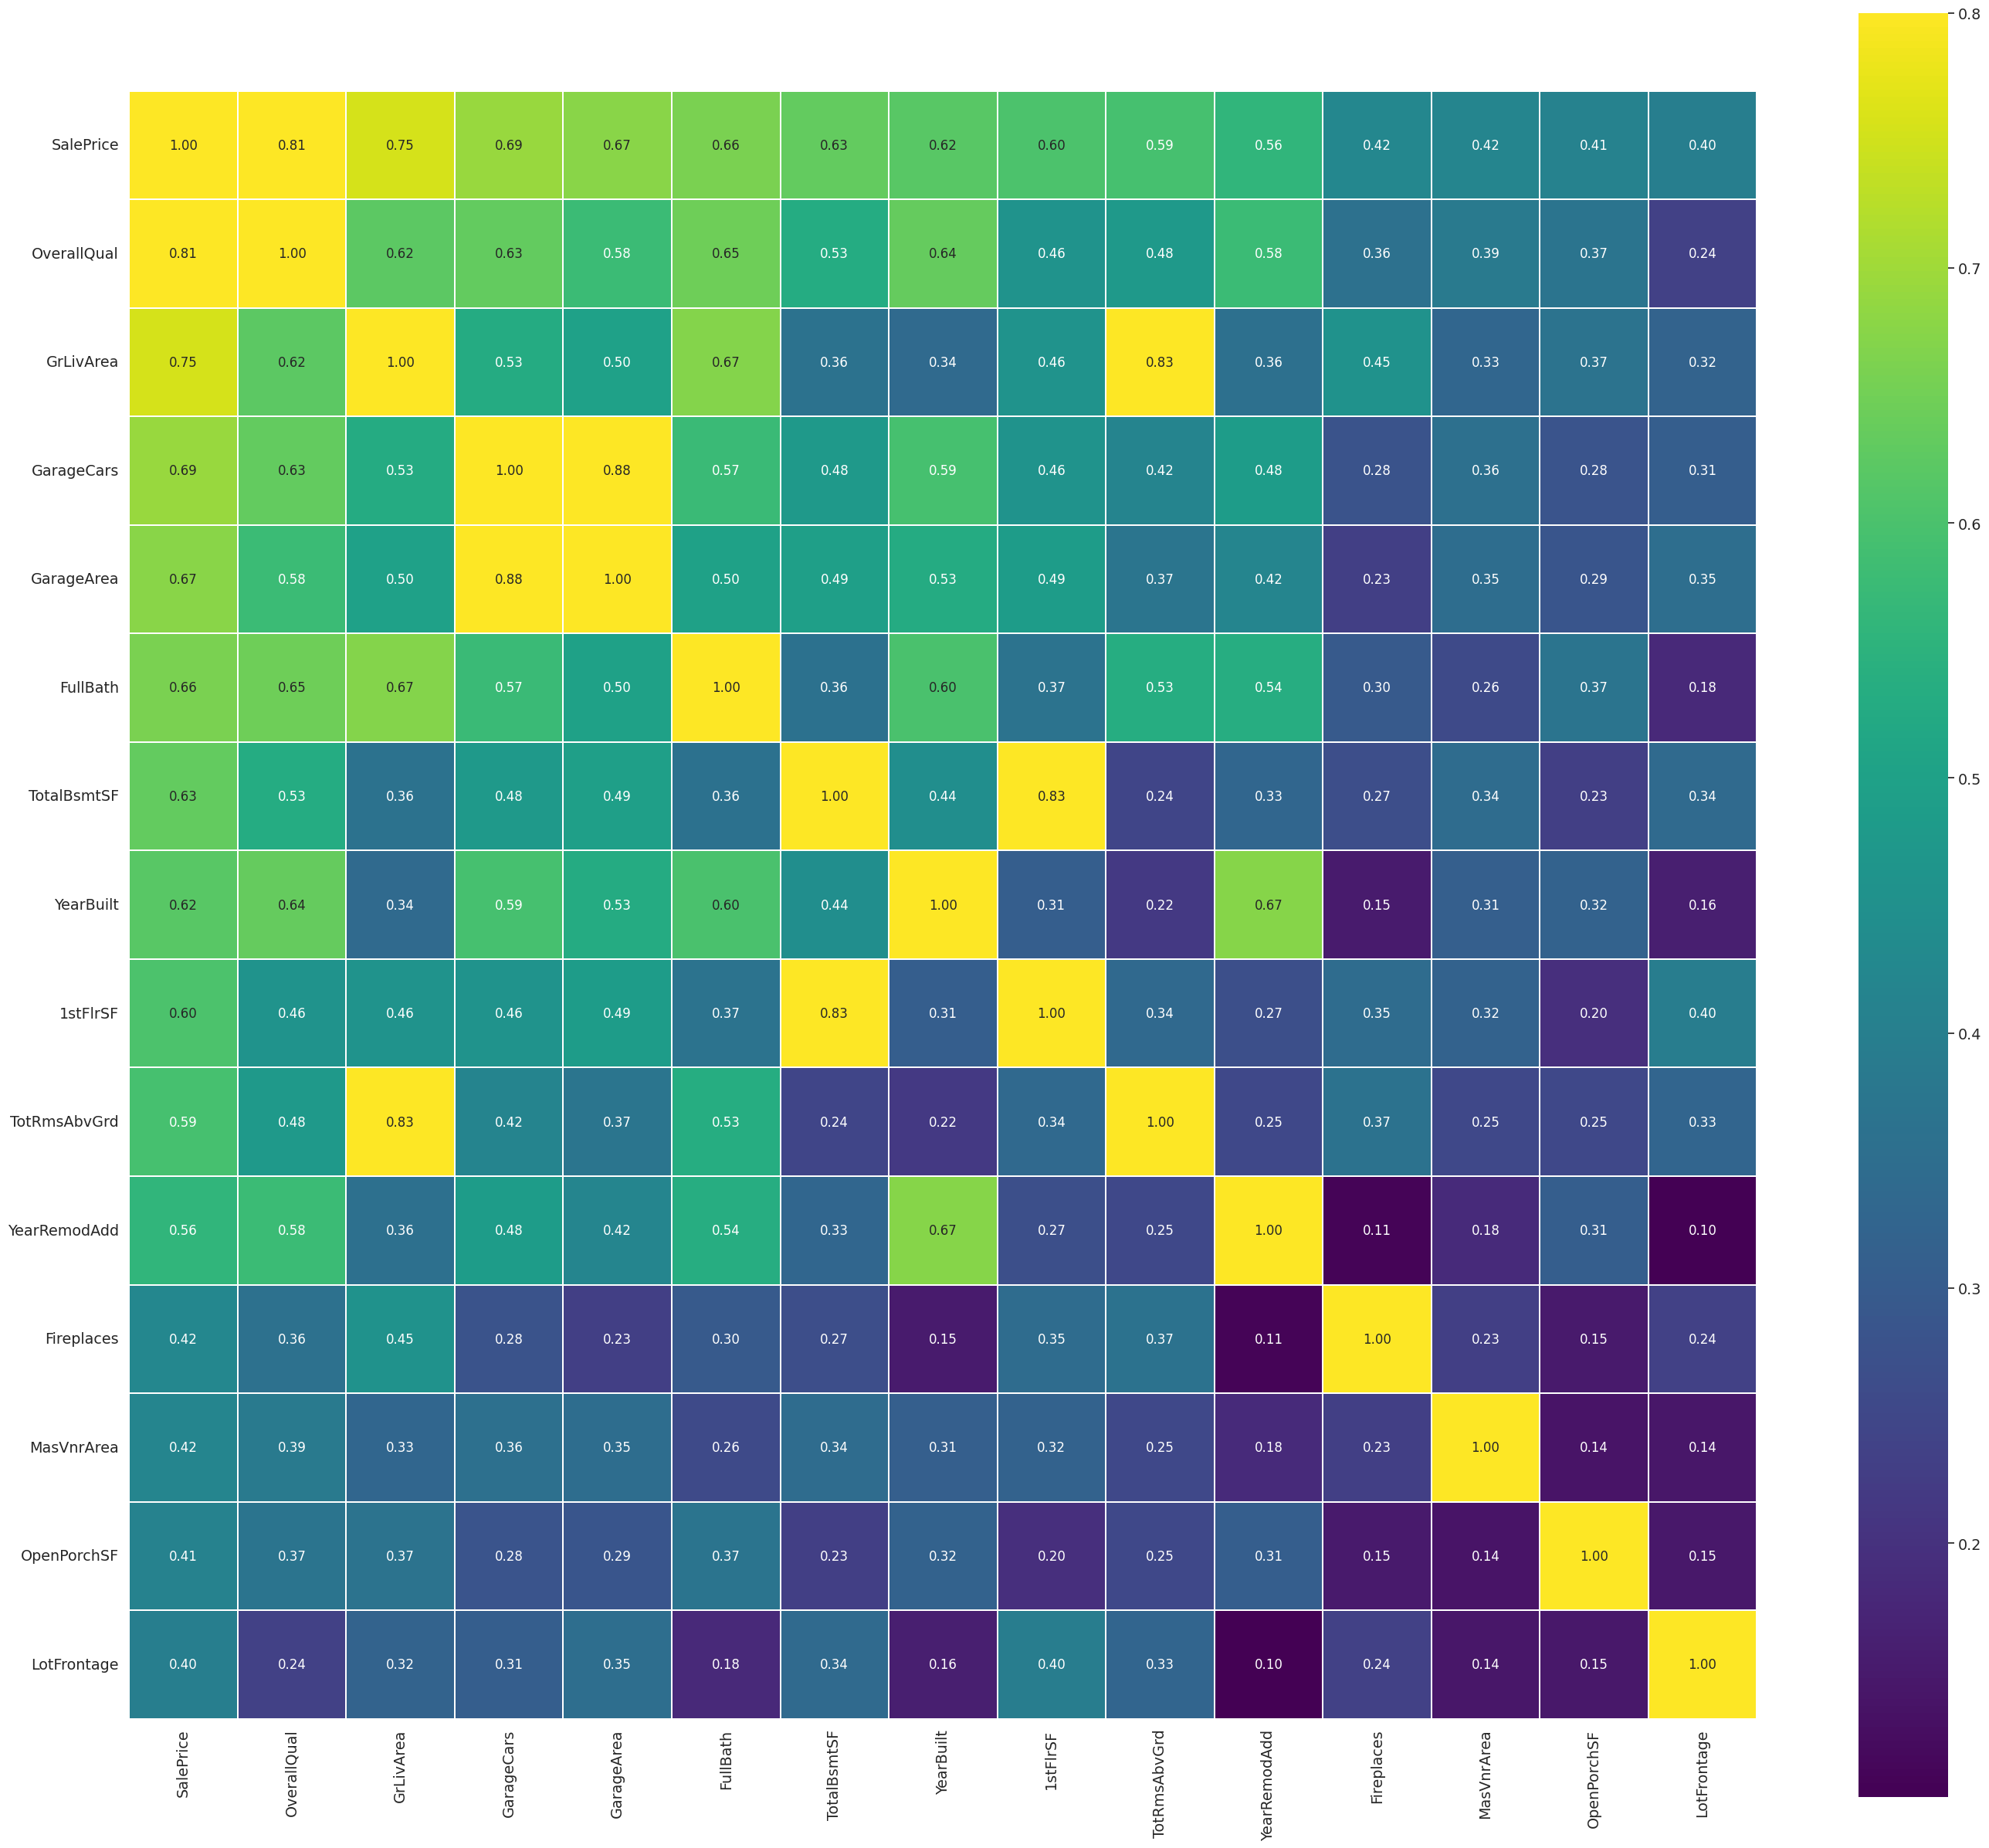

In [117]:
k = 15
cols = correlation.nlargest(k, 'SalePrice')['SalePrice'].index
print(cols)
cm = np.corrcoef(final_df[cols].values.T)
sns.set(font_scale=1.25)
f, ax = plt.subplots(figsize=(34, 30))
sns.heatmap(cm, vmax=0.8, linewidths=.01, cmap="viridis", linecolor='white', annot=True, square=True, fmt='.2f', annot_kws={'size': 12}, yticklabels=cols.values, xticklabels=cols.values)

In [118]:
# Find numerical features excluding 'SalePrice'
numerical_features_without_saleprice = final_df.select_dtypes(include=np.number).columns.tolist()
if 'SalePrice' in numerical_features_without_saleprice:
    numerical_features_without_saleprice.remove('SalePrice')

# Calculate the correlation matrix for independent variables
numerical_cols1 = final_df.select_dtypes(include=[np.number])
X_corr = final_df[numerical_features_without_saleprice].corr()

# Set a threshold for multicollinearity (e.g., absolute correlation greater than 0.7)
multicollinearity_threshold = 0.7

# Find features that are highly correlated with each other
high_corr_pairs = {}
for i in range(len(X_corr.columns)):
    for j in range(i):
        if abs(X_corr.iloc[i, j]) > multicollinearity_threshold:
            colname_i = X_corr.columns[i]
            colname_j = X_corr.columns[j]
            high_corr_pairs[(colname_i, colname_j)] = X_corr.iloc[i, j]

# Print the highly correlated pairs
if high_corr_pairs:
    print("Highly multicollinear features (absolute correlation > {}):".format(multicollinearity_threshold))
    for pair, corr_value in high_corr_pairs.items():
        print(f"  {pair[0]} and {pair[1]}: {corr_value:.4f}")
else:
    print("No highly multicollinear features found above the threshold of {}.".format(multicollinearity_threshold))


Highly multicollinear features (absolute correlation > 0.7):
  1stFlrSF and TotalBsmtSF: 0.8255
  TotRmsAbvGrd and GrLivArea: 0.8316
  GarageArea and GarageCars: 0.8814


In [119]:
# List features with poor correlation with 'SalePrice'
correlation_with_target = correlation['SalePrice'].sort_values()

# Set a threshold for poor correlation (e.g., absolute correlation less than 0.1 or 0.2)
poor_correlation_threshold = 0.34

poorly_correlated_features = correlation_with_target[abs(correlation_with_target) < poor_correlation_threshold]

print(f"\nFeatures with poor correlation (absolute correlation < {poor_correlation_threshold}) with 'SalePrice':")
poorly_correlated_features


Features with poor correlation (absolute correlation < 0.34) with 'SalePrice':


,SalePrice
EnclosedPorch,-0.192745
OverallCond,-0.158203
BsmtFinSF2,-0.105007
MiscVal,-0.070386
YrSold,-0.050341
KitchenAbvGr,-0.043141
MSSubClass,-0.032660
LowQualFinSF,-0.000401
BsmtHalfBath,0.018903
ScreenPorch,0.019156


In [120]:
columns_to_drop = ['1stFlrSF', 'TotRmsAbvGrd', 'GarageArea','EnclosedPorch','KitchenAbvGr','MSSubClass','OverallCond','LowQualFinSF','MiscVal','BsmtFinSF2','YrSold','BsmtHalfBath','MoSold','3SsnPorch','PoolArea','ScreenPorch','BedroomAbvGr','BsmtUnfSF','BsmtFullBath','HalfBath','2ndFlrSF','WoodDeckSF'
]
final_df.drop(columns=columns_to_drop, axis=1, inplace=True)
final_df.shape

(1020, 153)

### 2.2	Feature Binning: Bin continuous variables into discrete categories for better interpretability

In [121]:
final_df.head()

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,TotalBsmtSF,GrLivArea,FullBath,Fireplaces,GarageCars,OpenPorchSF,SalePrice,FV,RH,RL,RM,Pave,IR2,IR3,Reg,HLS,Low,Lvl,NoSeWa,CulDSac,FR2,FR3,Inside,Mod,Sev,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,MeadowV,Mitchel,NAmes,NPkVill,NWAmes,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker,Feedr,Norm,PosA,PosN,RRAe,RRAn,RRNe,RRNn,2fmCon,Duplex,Twnhs,TwnhsE,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl,Gable,Gambrel,Hip,Mansard,Shed,CompShg,Membran,Metal,Roll,Tar&Grv,WdShake,WdShngl,AsphShn,BrkComm,BrkFace,CBlock,CemntBd,HdBoard,ImStucc,MetalSd,Plywood,Stone,Stucco,VinylSd,Wd Sdng,WdShing,Brk Cmn,CmentBd,Other,Wd Shng,Fa,Gd,TA,Po,PConc,Slab,Wood,Mn,No,BLQ,GLQ,LwQ,Rec,Unf,GasA,GasW,Grav,OthW,Wall,Y,FuseF,FuseP,Mix,SBrkr,Maj2,Min1,Min2,Typ,Attchd,Basment,BuiltIn,CarPort,Detchd,RFn,P,CWD,Con,ConLD,ConLI,ConLw,New,Oth,WD,AdjLand,Alloca,Family,Normal,Partial
0,-0.229203,-0.207125,0.650852,1.051899,0.879449,0.513594,0.574748,-0.460570,0.370055,0.790180,-0.951848,0.311842,0.215983,208500,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,-0.092987,0.073401,0.650852,0.985650,0.830993,0.325449,0.092239,-0.314568,0.514687,0.790180,0.599824,0.311842,-0.070832,223500,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,0.633497,0.374967,1.374077,0.952526,0.734081,1.365783,0.462893,0.198720,1.298746,0.790180,0.599824,1.650010,0.563180,250000,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
3,0.224850,-0.043418,1.374077,1.085024,0.976361,0.458257,2.028854,1.432892,0.339606,0.790180,0.599824,0.311842,0.155601,307000,False,False,True,False,True,False,False,True,False,False,True,

In [122]:
from sklearn.preprocessing import KBinsDiscretizer

# Features to be binned using KBinsDiscretizer
features_to_discretize = ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', 'GrLivArea', 'FullBath', 'Fireplaces', 'GarageCars', 'OpenPorchSF']

# Initialize KBinsDiscretizer
discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile', subsample=None)

# Apply KBinsDiscretizer to the specified features
final_df[features_to_discretize] = discretizer.fit_transform(final_df[features_to_discretize])

print("KBinsDiscretizer applied to specified features.")

# Display head of the dataframe with the discretized features
print("\nHead of the dataframe with discretized features:")
print(final_df[features_to_discretize].head())


KBinsDiscretizer applied to specified features.

Head of the dataframe with discretized features:
   LotFrontage  LotArea  OverallQual  YearBuilt  YearRemodAdd  MasVnrArea  \
0          3.0      3.0          4.0        7.0           6.0         3.0   
1          4.0      7.0          4.0        7.0           5.0         2.0   
2          7.0      9.0          5.0        6.0           5.0         4.0   
3          6.0      6.0          5.0        8.0           7.0         3.0   
4          4.0      7.0          2.0        3.0           1.0         0.0   

   BsmtFinSF1  TotalBsmtSF  GrLivArea  FullBath  Fireplaces  GarageCars  \
0         4.0          3.0        7.0       2.0         0.0         2.0   
1         2.0          4.0        8.0       2.0         1.0         2.0   
2         4.0          6.0        9.0       2.0         1.0         3.0   
3         6.0          9.0        7.0       2.0         1.0         2.0   
4         5.0          5.0        2.0       1.0         0.0     

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306

In [123]:
final_df.head()

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,TotalBsmtSF,GrLivArea,FullBath,Fireplaces,GarageCars,OpenPorchSF,SalePrice,FV,RH,RL,RM,Pave,IR2,IR3,Reg,HLS,Low,Lvl,NoSeWa,CulDSac,FR2,FR3,Inside,Mod,Sev,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,MeadowV,Mitchel,NAmes,NPkVill,NWAmes,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker,Feedr,Norm,PosA,PosN,RRAe,RRAn,RRNe,RRNn,2fmCon,Duplex,Twnhs,TwnhsE,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl,Gable,Gambrel,Hip,Mansard,Shed,CompShg,Membran,Metal,Roll,Tar&Grv,WdShake,WdShngl,AsphShn,BrkComm,BrkFace,CBlock,CemntBd,HdBoard,ImStucc,MetalSd,Plywood,Stone,Stucco,VinylSd,Wd Sdng,WdShing,Brk Cmn,CmentBd,Other,Wd Shng,Fa,Gd,TA,Po,PConc,Slab,Wood,Mn,No,BLQ,GLQ,LwQ,Rec,Unf,GasA,GasW,Grav,OthW,Wall,Y,FuseF,FuseP,Mix,SBrkr,Maj2,Min1,Min2,Typ,Attchd,Basment,BuiltIn,CarPort,Detchd,RFn,P,CWD,Con,ConLD,ConLI,ConLw,New,Oth,WD,AdjLand,Alloca,Family,Normal,Partial
0,3.0,3.0,4.0,7.0,6.0,3.0,4.0,3.0,7.0,2.0,0.0,2.0,3.0,208500,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,4.0,7.0,4.0,7.0,5.0,2.0,2.0,4.0,8.0,2.0,1.0,2.0,2.0,223500,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,7.0,9.0,5.0,6.0,5.0,4.0,4.0,6.0,9.0,2.0,1.0,3.0,4.0,250000,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
3,6.0,6.0,5.0,8.0,7.0,3.0,6.0,9.0,7.0,2.0,1.0,2.0,3.0,307000,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,Fa

### 3.1	Analysis and Interpretation: Analyse the dataset to answer specific questions:


## I. What is the distribution of sale prices?

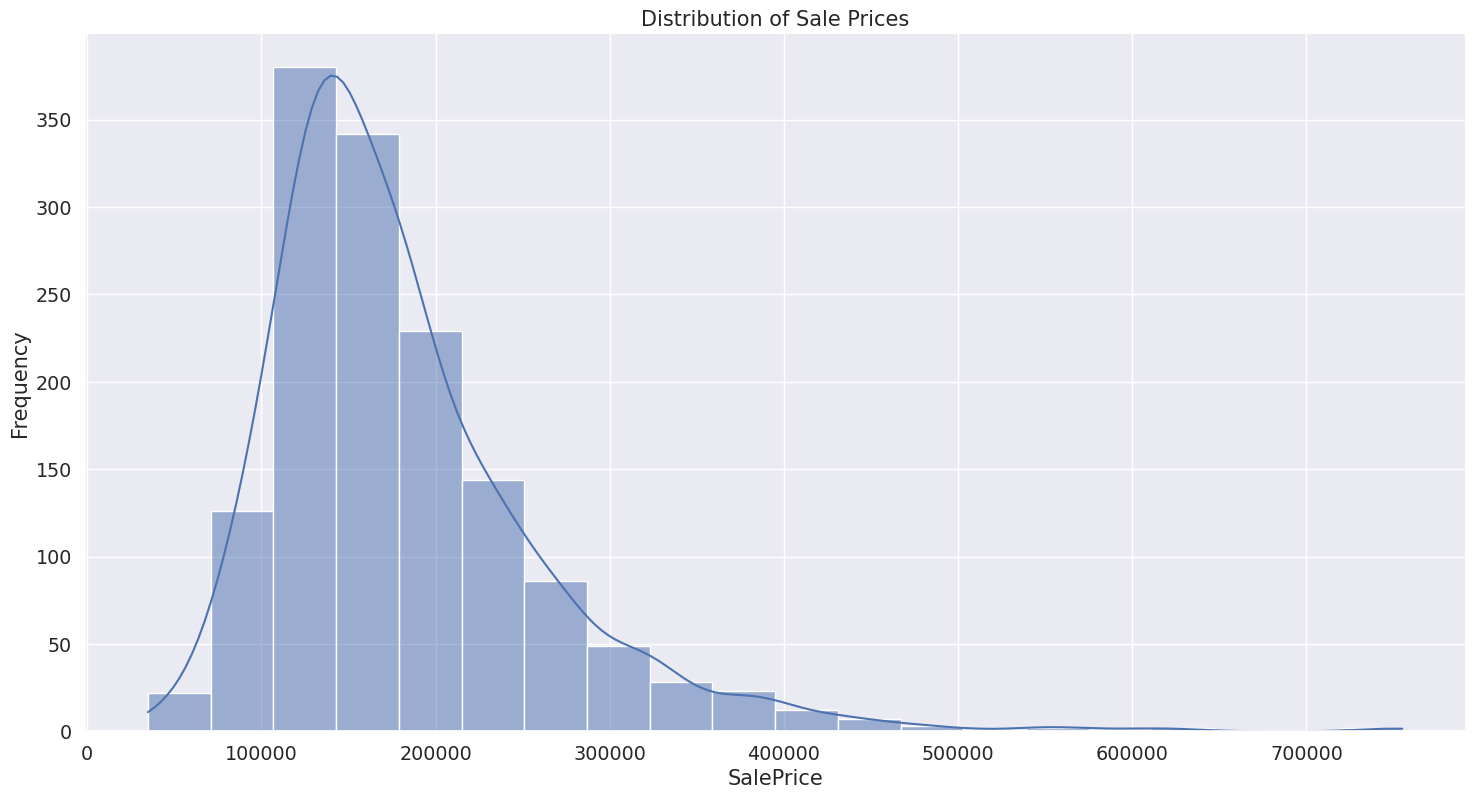

In [124]:
sns.displot(df['SalePrice'], kde=True, bins=20, height=8, aspect=15/8)
plt.title('Distribution of Sale Prices')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()


*  Using `sns.displot(df['SalePrice'], kde=True, bins=20)` to show the distribution of SalePrice.
######      *the distribution of SalePrice is right-skewed*

## II. How do different features relate to sale price?

Visualizing relationships between features and SalePrice...


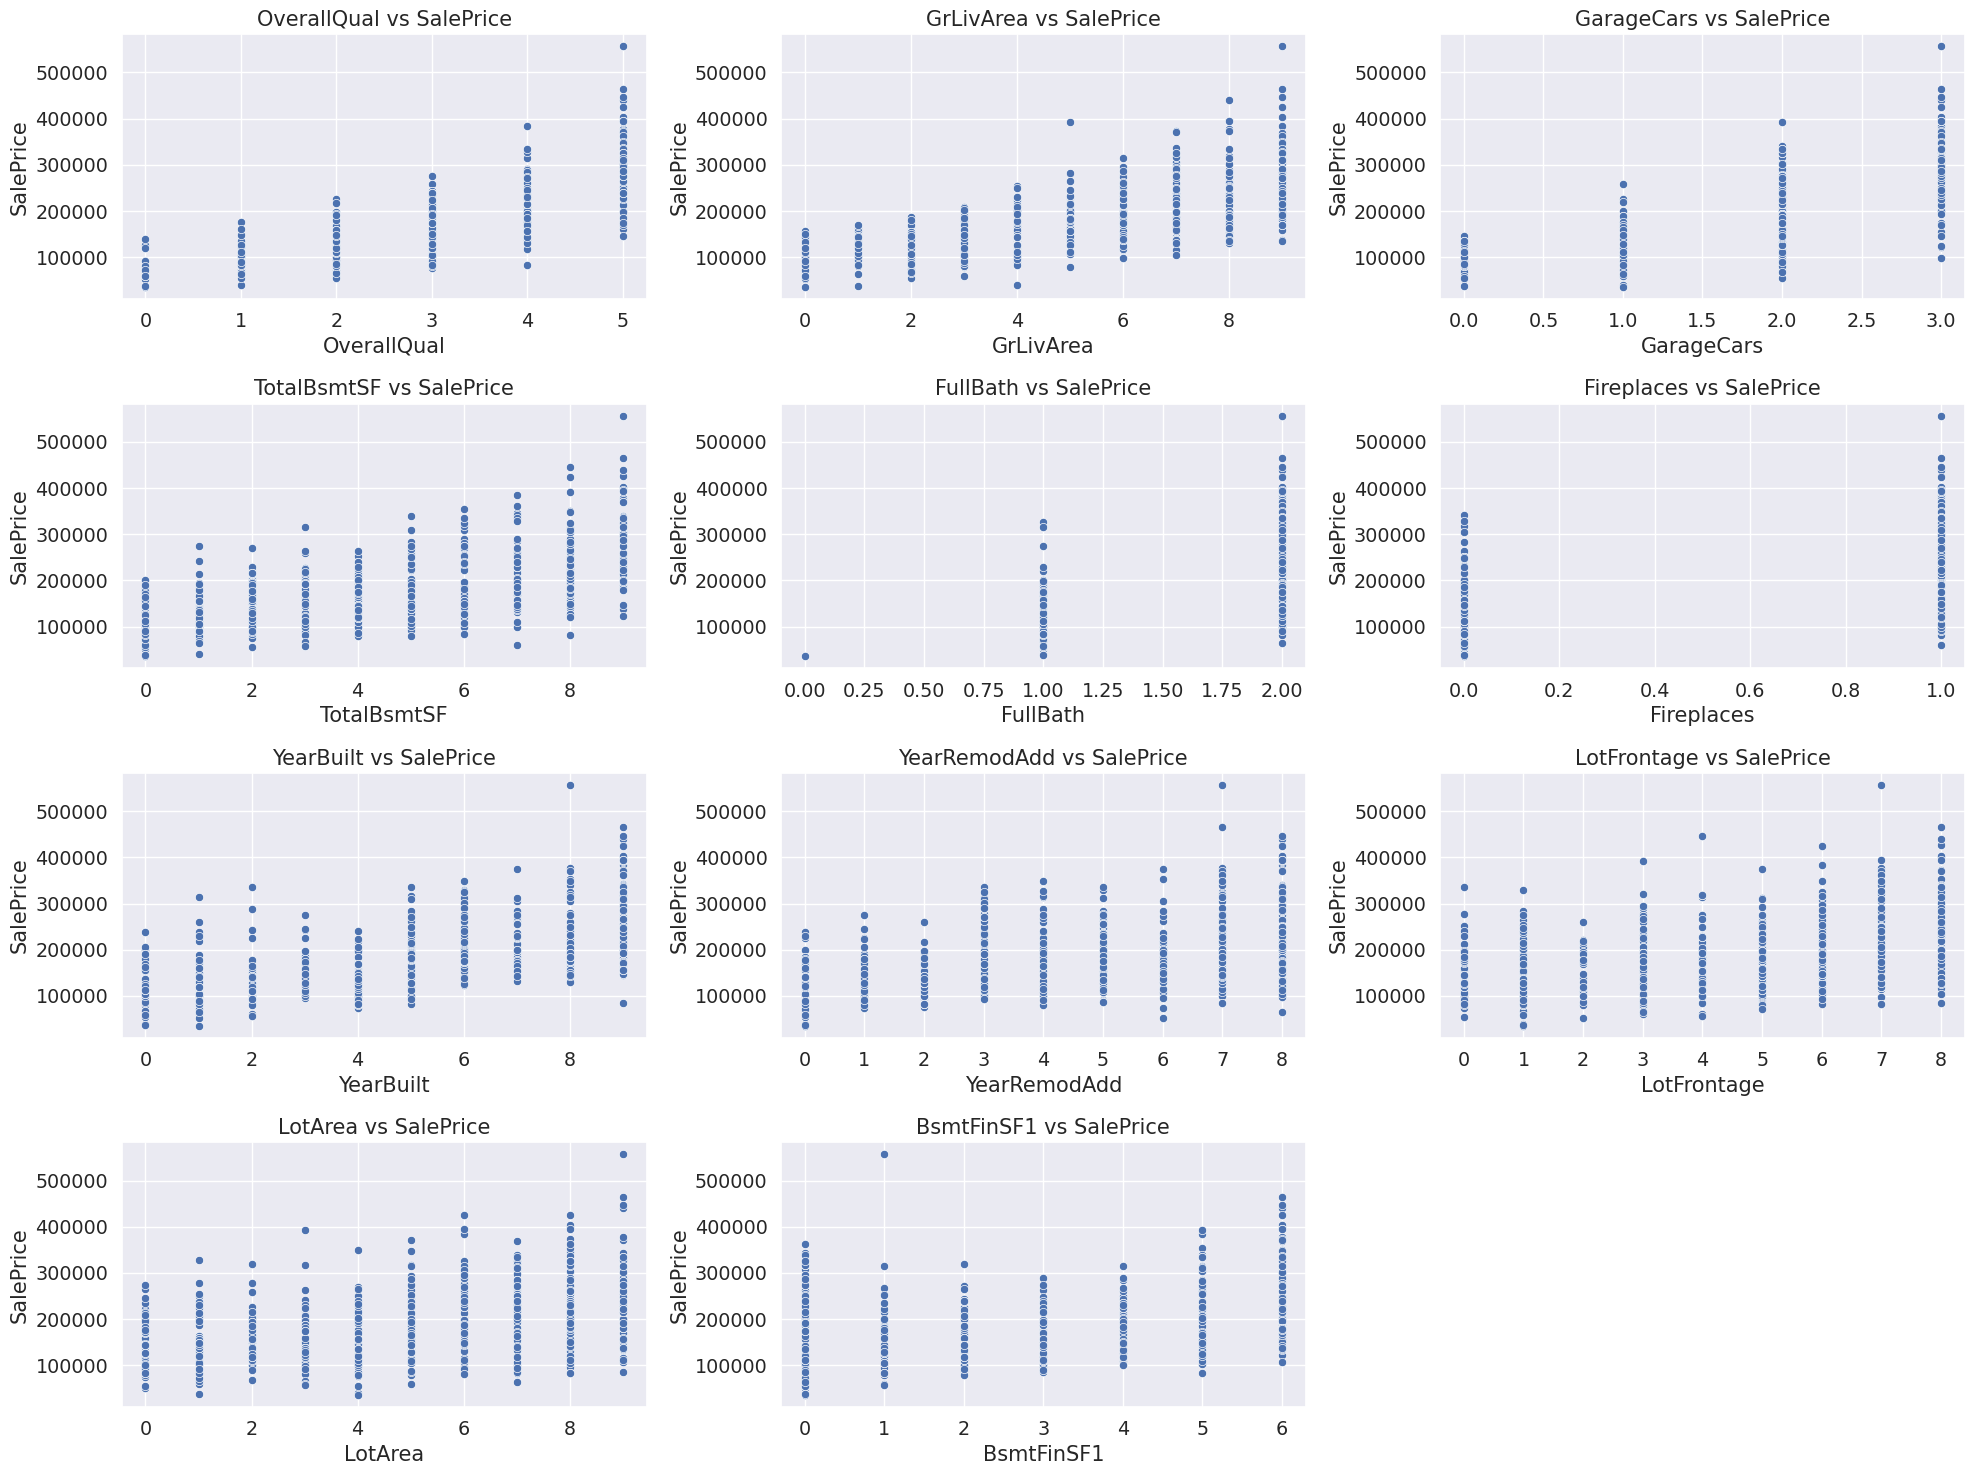

In [125]:
# Get the list of numerical features again (excluding SalePrice)
numerical_features_for_relationship = final_df.select_dtypes(include=np.number).columns.tolist()
if 'SalePrice' in numerical_features_for_relationship:
    numerical_features_for_relationship.remove('SalePrice')

print("Visualizing relationships between features and SalePrice...")

# Select a few key features to visualize relationships
features_to_visualize = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
    'FullBath', 'Fireplaces', 'YearBuilt', 'YearRemodAdd',
    # Include some binned features
    'LotFrontage', 'LotArea', 'BsmtFinSF1'
]

# Ensure selected features are present in the dataframe
features_to_visualize = [f for f in features_to_visualize if f in final_df.columns]

plt.figure(figsize=(20, 15))

for i, col in enumerate(features_to_visualize):
    plt.subplot(math.ceil(len(features_to_visualize)/3), 3, i + 1) # Create subplots
    sns.scatterplot(x=final_df[col], y=final_df['SalePrice'])
    plt.title(f'{col} vs SalePrice')
    plt.xlabel(col)
    plt.ylabel('SalePrice')

plt.tight_layout()
plt.show()




Visualizing relationships between original categorical features and SalePrice...


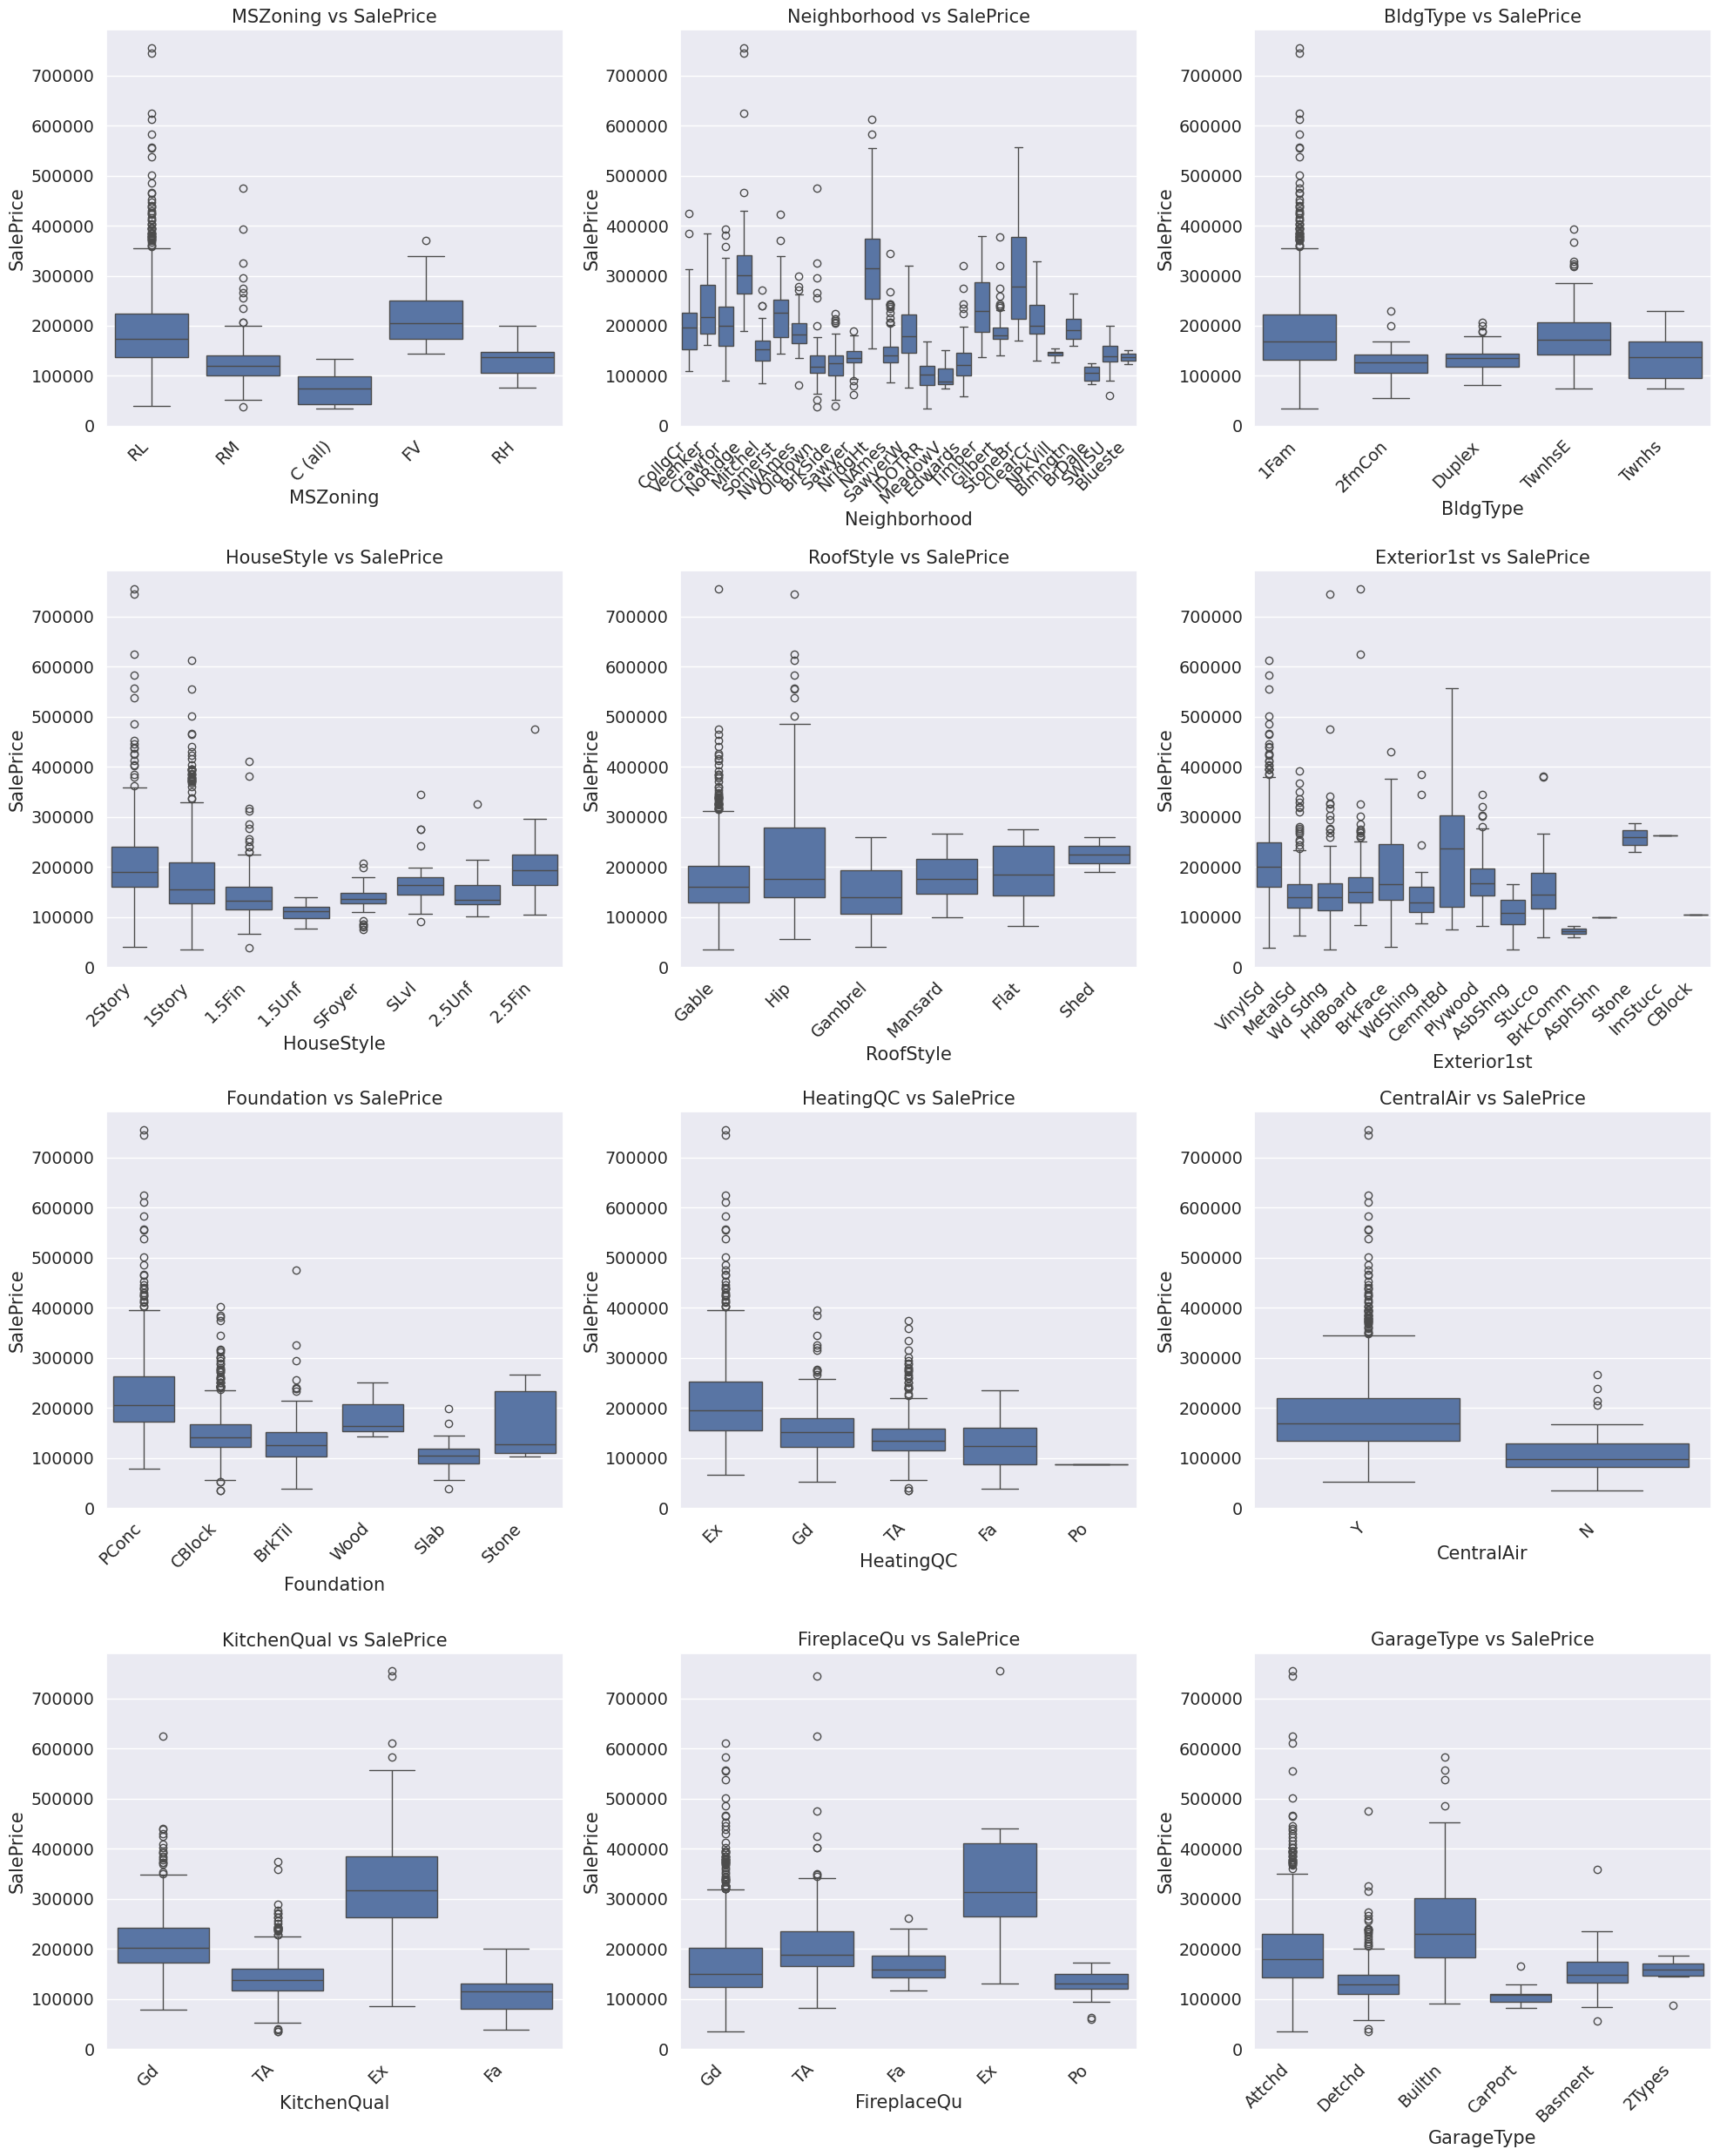

In [126]:
# For categorical features (which are now one-hot encoded ),

if 'df' in locals() and not df.empty:
    print("\nVisualizing relationships between original categorical features and SalePrice...")
    categorical_features_original = df.select_dtypes(include='object').columns.tolist()

    # Select a few key categorical features to visualize
    categorical_features_to_visualize = [
        'MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle',
        'RoofStyle', 'Exterior1st', 'Foundation', 'HeatingQC',
        'CentralAir', 'KitchenQual', 'FireplaceQu', 'GarageType'
    ]

    # Ensure selected features are present in the dataframe
    categorical_features_to_visualize = [f for f in categorical_features_to_visualize if f in df.columns]

    plt.figure(figsize=(20, 25))

    for i, col in enumerate(categorical_features_to_visualize):
        plt.subplot(math.ceil(len(categorical_features_to_visualize)/3), 3, i + 1) # Create subplots
        sns.boxplot(x=df[col], y=df['SalePrice'])
        plt.title(f'{col} vs SalePrice')
        plt.xlabel(col)
        plt.ylabel('SalePrice')
        plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
else:
    print("\nOriginal dataframe 'df' not available or empty. Cannot visualize original categorical features.")


######   *Based on these visualizations and the correlation values, we can infer:*
###### - *Features like 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF' tend to have strong positive relationships with SalePrice.*
###### - *The relationship between binned features and SalePrice can show if certain bins (ranges of the original feature) correspond to significantly different SalePrices.*

#####   A clear upward trend suggests a positive correlation (as feature value increases, SalePrice tends to increase).
##### - For categorical features, some categories within a feature (e.g., 'Neighborhood', 'KitchenQual') clearly
#####   correspond to higher or lower average SalePrices.

##### This analysis helps in understanding which features are potentially more important for predicting SalePrice.

## III. Identify trends and patterns in the data.

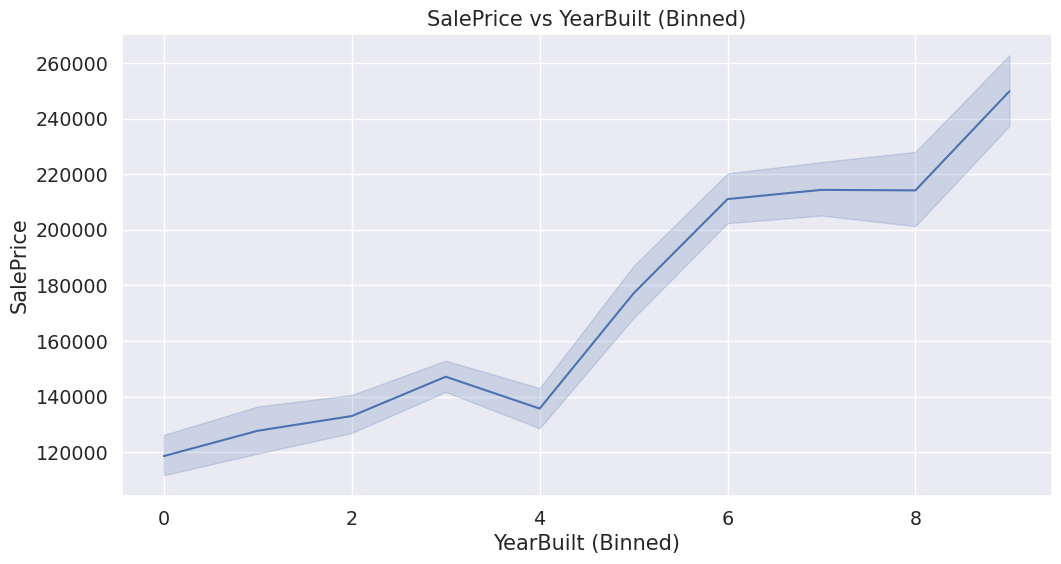

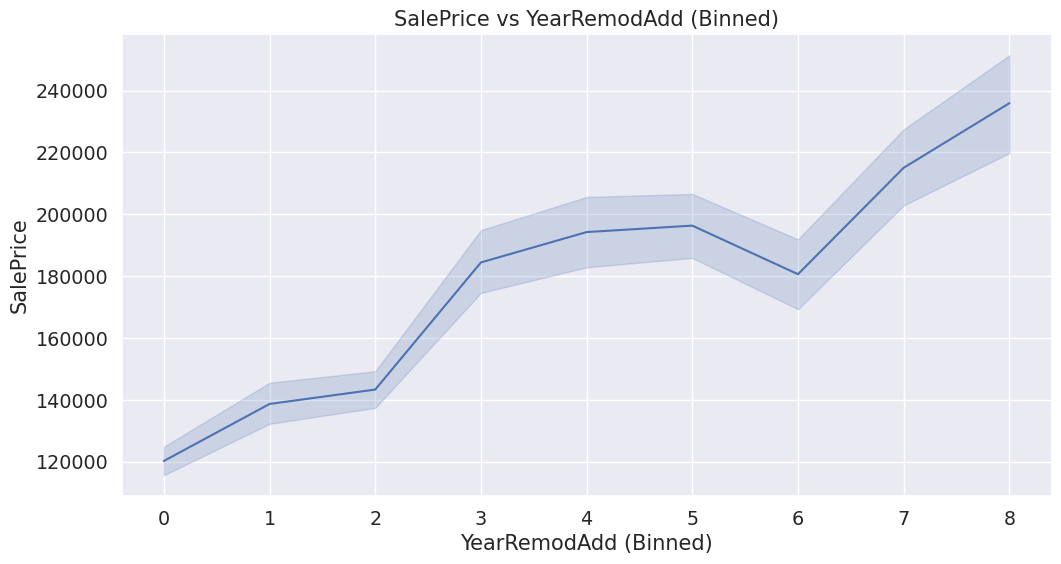

In [127]:
# - Trends: Observing the relationships above helps identify trends (e.g., SalePrice tends to increase with
#   Overall Quality or Living Area).
# - Patterns: Patterns can be seen in the distributions (e.g., the distribution of SalePrice is right-skewed),
#   in the scatter plots (clusters of points, non-linear relationships), or in the box plots (distinct differences
#   between categories).
# - Time-based trends: Looking at features like 'YearBuilt' or 'YearRemodAdd' vs SalePrice can reveal trends over time.

plt.figure(figsize=(12, 6))
sns.lineplot(x=final_df['YearBuilt'], y=final_df['SalePrice'])
plt.title('SalePrice vs YearBuilt (Binned)')
plt.xlabel('YearBuilt (Binned)')
plt.ylabel('SalePrice')
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(x=final_df['YearRemodAdd'], y=final_df['SalePrice'])
plt.title('SalePrice vs YearRemodAdd (Binned)')
plt.xlabel('YearRemodAdd (Binned)')
plt.ylabel('SalePrice')
plt.show()

##### These line plots for binned year features show if newer houses or recently remodeled houses tend to have higher sale prices on average across the bins.

##### Further patterns could involve interactions between features, but that's harder to visualize directly
##### without creating interaction features explicitly and then analyzing their relationship with the target.

## Feature Selection

In [128]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

# to visualise al the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)
## Capture the dependent feature
y_train=final_df[['SalePrice']]
## drop dependent feature from dataset
X_train=final_df.drop(['SalePrice'],axis=1)

In [129]:

### Apply Feature Selection
# first, I specify the Lasso Regression model, and I
# select a suitable alpha (equivalent of penalty).
# The bigger the alpha the less features that will be selected.

# Then I use the selectFromModel object from sklearn, which
# will select the features which coefficients are non-zero

feature_sel_model = SelectFromModel(Lasso(alpha=0.005, random_state=42)) # remember to set the seed, the random state in this function
feature_sel_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.125e+08, tolerance: 4.592e+08
  model = cd_fast.enet_coordinate_descent(


SelectFromModel(estimator=Lasso(alpha=0.005, random_state=42))

In [130]:
feature_sel_model.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True, False,
       False, False,  True, False,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
       False,  True,

In [131]:
# this is how we can make a list of the selected features
selected_feat = X_train.columns[(feature_sel_model.get_support())]

# let's print some stats
print('total features: {}'.format((X_train.shape[1])))
print('selected features: {}'.format(len(selected_feat)))
print('features with coefficients shrank to zero: {}'.format(
    np.sum(feature_sel_model.estimator_.coef_ == 0)))

total features: 152
selected features: 141
features with coefficients shrank to zero: 11


In [132]:
selected_feat


Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', 'GrLivArea', 'FullBath',
       ...
       'ConLI', 'ConLw', 'New', 'Oth', 'WD', 'AdjLand', 'Alloca', 'Family',
       'Normal', 'Partial'],
      dtype='object', length=141)

### I.	Build models using XGBoost, LightGBM, and CatBoost to predict sale prices.

In [133]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module="LightGBM")

from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Define features (X) and target (y)
X = final_df[selected_feat]
y = final_df['SalePrice']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100),
    'LightGBM': lgb.LGBMRegressor(random_state=42, n_estimators=100),
    'CatBoost': CatBoostRegressor(random_state=42, iterations=100, verbose=0)
}

# Evaluate models using cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    # Use negative mean squared error as the scoring metric
    # cross_val_score returns negative values for metrics where higher is better,
    # so we take the absolute value and then the square root for RMSE
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    mean_rmse = rmse_scores.mean()
    std_rmse = rmse_scores.std()
    results[name] = {'Mean RMSE (CV)': mean_rmse, 'Std Dev RMSE (CV)': std_rmse}
    print(f"{name}: Mean RMSE (CV) = {mean_rmse:.4f} (+/- {std_rmse:.4f})")




XGBoost: Mean RMSE (CV) = 24096.5718 (+/- 4688.6844)
LightGBM: Mean RMSE (CV) = 22760.5616 (+/- 3707.5869)
CatBoost: Mean RMSE (CV) = 21771.2794 (+/- 4021.0333)


In [134]:
# Hyperparameter Tuning using RandomizedSearchCV

# Define parameter distributions for RandomizedSearchCV

# XGBoost parameters
# xgb_param_dist = {
#     'n_estimators': [100, 200, 500, 700],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'max_depth': [3, 4, 5, 6, 7, 8],
#     'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
#     'min_child_weight': [1, 3, 5, 7],
#     'gamma': [0, 0.1, 0.2, 0.3, 0.4],
#     'reg_alpha': [0, 0.001, 0.01, 0.1, 1],
#     'reg_lambda': [0, 0.001, 0.01, 0.1, 1]
# }

# LightGBM parameters
# lgb_param_dist = {
#     'n_estimators': [100, 200, 500, 700],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'num_leaves': [20, 31, 40, 50],
#     'max_depth': [-1, 5, 7, 10], # -1 means no limit
#     'min_child_samples': [20, 30, 50, 100],
#     'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
#     'reg_alpha': [0, 0.001, 0.01, 0.1, 1],
#     'reg_lambda': [0, 0.001, 0.01, 0.1, 1]
# }

# CatBoost parameters (simplified for faster execution, more comprehensive search is possible)
# cat_param_dist = {
#     'iterations': [100, 200, 500, 700],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'depth': [3, 4, 5, 6, 7, 8],
#     'l2_leaf_reg': [1, 3, 5, 7, 9],
#     'border_count': [32, 64, 128],
#     'random_strength': [0.5, 1, 1.5, 2]
# }

# Perform RandomizedSearchCV for each model
# tuned_results = {}

# print("\nPerforming RandomizedSearchCV...")

# # XGBoost Tuning
# print("Tuning XGBoost...")
# xgb_random = RandomizedSearchCV(
#     estimator=XGBRegressor(random_state=42, eval_metric='rmse'), # Use rmse as eval_metric
#     param_distributions=xgb_param_dist,
#     n_iter=50,  # Number of parameter settings that are sampled
#     cv=kf,
#     scoring='neg_mean_squared_error',
#     verbose=0,
#     n_jobs=-1, # Use all available cores
#     random_state=42
# )
# xgb_random.fit(X_train, y_train)
# tuned_results['XGBoost'] = {
#     'Best Params': xgb_random.best_params_,
#     'Best RMSE (CV)': np.sqrt(-xgb_random.best_score_)
# }


# # LightGBM Tuning
# print("\nTuning LightGBM...")
# lgb_random = RandomizedSearchCV(
#     estimator=lgb.LGBMRegressor(random_state=42),
#     param_distributions=lgb_param_dist,
#     n_iter=50, # Number of parameter settings that are sampled
#     cv=kf,
#     scoring='neg_mean_squared_error',
#     verbose=0,
#     n_jobs=-1, # Use all available cores
#     random_state=42
# )
# lgb_random.fit(X_train, y_train)
# tuned_results['LightGBM'] = {
#     'Best Params': lgb_random.best_params_,
#     'Best RMSE (CV)': np.sqrt(-lgb_random.best_score_)
# }


# # CatBoost Tuning
# print("\nTuning CatBoost...")
# # For CatBoost, need to explicitly handle categorical features if they weren't one-hot encoded.
# # Since we did one-hot encoding, we don't need to pass categorical_features_indices.
# cat_random = RandomizedSearchCV(
#     estimator=CatBoostRegressor(random_state=42, verbose=0),
#     param_distributions=cat_param_dist,
#     n_iter=20, # Reduced iterations for CatBoost due to potentially longer training time
#     cv=kf,
#     scoring='neg_mean_squared_error',
#     verbose=0,
#     n_jobs=-1, # Use all available cores
#     random_state=42
# )
# cat_random.fit(X_train, y_train)
# tuned_results['CatBoost'] = {
#     'Best Params': cat_random.best_params_,
#     'Best RMSE (CV)': np.sqrt(-cat_random.best_score_)
# }



# # Print final tuned results
# print("\n--- Tuned Model Performance (RandomizedSearchCV) ---")
# for name, result in tuned_results.items():
#     print(f"{name}: Best RMSE (CV) = {result['Best RMSE (CV)']:.4f}, Best Params: {result['Best Params']}")

# # Train best models on the full training data and evaluate on the test set

# best_xgb = xgb_random.best_estimator_
# best_lgb = lgb_random.best_estimator_
# best_cat = cat_random.best_estimator_


#OUTPUT

#XGBoost: Best RMSE (CV) = 34333.7887, Best Params: {'subsample': 0.6, 'reg_lambda': 0.001, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.6}
#LightGBM: Best RMSE (CV) = 35023.7839, Best Params: {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 20, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
#CatBoost: Best RMSE (CV) = 33338.2346, Best Params: {'random_strength': 2, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 8, 'border_count': 128}



In [135]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module="lightgbm")

# Define best parameters based on previous RandomizedSearchCV results
best_xgb_params = {'subsample': 0.6, 'reg_lambda': 0.001, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 5,
                   'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.6}

best_lgb_params = {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 20, 'n_estimators': 500,
                   'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.6,  'verbose': -1} # Set verbose to -1 to silence warnings

best_cat_params = {'random_strength': 2, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 8,
                   'border_count': 128}

# Initialize models with the best parameters
model_xgb = XGBRegressor(**best_xgb_params, random_state=42, enable_categorical=False) # Explicitly set enable_categorical if needed, but likely not after one-hot
model_lgb = lgb.LGBMRegressor(**best_lgb_params, random_state=42)
model_cat = CatBoostRegressor(**best_cat_params, random_state=42, verbose=0) # Set verbose to 0 to silence training output

# Train the models on the training data
print("Training models with best parameters...")
model_xgb.fit(X_train, y_train)
model_lgb.fit(X_train, y_train)
model_cat.fit(X_train, y_train)

# Make predictions on the test set
print("Making predictions on the test set...")
y_pred_xgb = model_xgb.predict(X_test)
y_pred_lgb = model_lgb.predict(X_test)
y_pred_cat = model_cat.predict(X_test)



Training models with best parameters...
Making predictions on the test set...


In [136]:
# Evaluate model performance using metrics such as RMSE, MAE, and R²
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

# Calculate RMSE (Root Mean Squared Error)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
rmse_lgb = root_mean_squared_error(y_test, y_pred_lgb)
rmse_cat = root_mean_squared_error(y_test, y_pred_cat)

# Calculate MAE (Mean Absolute Error)
from sklearn.metrics import mean_absolute_error
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mae_cat = mean_absolute_error(y_test, y_pred_cat)

# Calculate R² (R-squared)
r2_xgb = r2_score(y_test, y_pred_xgb)
r2_lgb = r2_score(y_test, y_pred_lgb)
r2_cat = r2_score(y_test, y_pred_cat)

print("\n--- Model Performance Metrics on Test Set ---")

print("\nXGBoost:")
print(f"  RMSE: {rmse_xgb:.4f}")
print(f"  MAE:  {mae_xgb:.4f}")
print(f"  R²:   {r2_xgb:.4f}")

print("\nLightGBM:")
print(f"  RMSE: {rmse_lgb:.4f}")
print(f"  MAE:  {mae_lgb:.4f}")
print(f"  R²:   {r2_lgb:.4f}")

print("\nCatBoost:")
print(f"  RMSE: {rmse_cat:.4f}")
print(f"  MAE:  {mae_cat:.4f}")
print(f"  R²:   {r2_cat:.4f}")



--- Model Performance Metrics on Test Set ---

XGBoost:
  RMSE: 23667.7695
  MAE:  14539.6689
  R²:   0.8924

LightGBM:
  RMSE: 25372.4323
  MAE:  15675.6298
  R²:   0.8763

CatBoost:
  RMSE: 24359.4952
  MAE:  14840.9395
  R²:   0.8860
